## CÉLULA 0 — INSTALAÇÃO (execute apenas uma vez no Colab)

In [77]:
# =============================================================================
# CÉLULA 0 — INSTALAÇÃO (execute apenas uma vez no Colab)
# =============================================================================
# !pip install yfinance python-bcb pandas numpy matplotlib seaborn scikit-learn \
#              statsmodels transformers torch nltk requests reportlab --quiet

## CÉLULA 1 — IMPORTS E CONFIGURAÇÃO GLOBAL

In [78]:
# =============================================================================
# CÉLULA 1 — IMPORTS E CONFIGURAÇÃO GLOBAL
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import re, math, time, io, os, textwrap
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns

import yfinance as yf
import requests

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# python-bcb
try:
    from bcb import sgs as bcb_sgs
    BCB_AVAILABLE = True
except ImportError:
    BCB_AVAILABLE = False

# reportlab
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table,
                                 TableStyle, PageBreak, Image as RLImage,
                                 HRFlowable)
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_JUSTIFY

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
TRADING_DAYS = 252

CORES = {
    "azul":    "#1a73e8",
    "laranja": "#e8710a",
    "verde":   "#34a853",
    "vermelho":"#ea4335",
    "cinza":   "#9aa0a6",
    "fundo":   "#f8f9fa",
    "roxo":    "#7b1fa2",
    "ouro":    "#f9a825",
}

plt.rcParams.update({
    "figure.figsize":  (12, 5),
    "axes.grid":       True,
    "axes.facecolor":  CORES["fundo"],
    "grid.alpha":      0.35,
    "font.size":       10,
})

# Pasta para salvar figuras do relatório
FIG_DIR = "/tmp/figs_relatorio"
os.makedirs(FIG_DIR, exist_ok=True)

FIG_PATHS = []   # acumula caminhos para o PDF

def salvar_fig(nome):
    """Salva a figura atual em PNG e registra o caminho."""
    path = os.path.join(FIG_DIR, f"{nome}.png")
    plt.savefig(path, dpi=120, bbox_inches="tight")
    FIG_PATHS.append(path)
    plt.show()
    return path

print("✅ Bibliotecas carregadas com sucesso.")

✅ Bibliotecas carregadas com sucesso.


## CÉLULA 2 — INPUTS DO USUÁRIO (apenas o essencial)

In [79]:
1# =============================================================================
# CÉLULA 2 — INPUTS DO USUÁRIO (apenas o essencial)
# =============================================================================

print("=" * 65)
print("  LABORATÓRIO DE FINANÇAS QUANTITATIVAS — CONFIGURAÇÃO")
print("=" * 65)

_ticker_raw = input(
    "\n📌 Tickers (separados por vírgula, ex.: VALE3.SA,PETR4.SA,ITUB4.SA): "
).strip()
TICKERS = [t.strip().upper() for t in _ticker_raw.split(",") if t.strip()]

cenario_map = {"1": "Bull", "2": "Base", "3": "Bear"}
print("\n🌐 Cenário macroeconômico:  1=Bull  2=Base  3=Bear")
CENARIO = cenario_map.get(input("Escolha (1/2/3) [padrão=2]: ").strip() or "2", "Base")

perfil_map = {"1": "Conservador", "2": "Moderado", "3": "Agressivo"}
print("\n🎯 Perfil:  1=Conservador  2=Moderado  3=Agressivo")
PERFIL = perfil_map.get(input("Escolha (1/2/3) [padrão=2]: ").strip() or "2", "Moderado")

_periodo = input("\n📅 Período histórico (ex.: 5y, 3y) [padrão=5y]: ").strip() or "5y"
PERIODO = _periodo

print(f"\n✅ Tickers: {TICKERS} | Cenário: {CENARIO} | Perfil: {PERFIL} | Período: {PERIODO}")

  LABORATÓRIO DE FINANÇAS QUANTITATIVAS — CONFIGURAÇÃO

📌 Tickers (separados por vírgula, ex.: VALE3.SA,PETR4.SA,ITUB4.SA): VALE3.SA,PETR4.SA,ITUB4.SA

🌐 Cenário macroeconômico:  1=Bull  2=Base  3=Bear
Escolha (1/2/3) [padrão=2]: 2

🎯 Perfil:  1=Conservador  2=Moderado  3=Agressivo
Escolha (1/2/3) [padrão=2]: 2

📅 Período histórico (ex.: 5y, 3y) [padrão=5y]: 5y

✅ Tickers: ['VALE3.SA', 'PETR4.SA', 'ITUB4.SA'] | Cenário: Base | Perfil: Moderado | Período: 5y


## CÉLULA 3 — MAPEAMENTO DE SETORES (yfinance → classificação própria)

In [80]:
# =============================================================================
# CÉLULA 3 — MAPEAMENTO DE SETORES (yfinance → classificação própria)
# =============================================================================

# Mapeamento: setor yfinance → setor simplificado
YF_SETOR_MAP = {
    "Technology":                  "Tecnologia",
    "Financial Services":          "Financeiro",
    "Basic Materials":             "Energia",
    "Energy":                      "Energia",
    "Utilities":                   "Utilities",
    "Consumer Cyclical":           "Consumo",
    "Consumer Defensive":          "Consumo",
    "Healthcare":                  "Saúde",
    "Industrials":                 "Industrial",
    "Real Estate":                 "Utilities",
    "Communication Services":     "Tecnologia",
    "Financial":                   "Financeiro",
    "Materials":                   "Energia",
}

# Limites setoriais (regras de negócio)
LIMITES_SETOR = {
    "Utilities":   {"dl_ebitda_max": 5.0, "margem_min": 0.12, "roe_min": 0.08},
    "Energia":     {"dl_ebitda_max": 4.5, "margem_min": 0.15, "roe_min": 0.10},
    "Financeiro":  {"dl_ebitda_max": 8.0, "margem_min": 0.20, "roe_min": 0.12},
    "Industrial":  {"dl_ebitda_max": 3.0, "margem_min": 0.10, "roe_min": 0.08},
    "Consumo":     {"dl_ebitda_max": 3.5, "margem_min": 0.08, "roe_min": 0.10},
    "Tecnologia":  {"dl_ebitda_max": 2.0, "margem_min": 0.18, "roe_min": 0.12},
    "Saúde":       {"dl_ebitda_max": 3.0, "margem_min": 0.12, "roe_min": 0.10},
    "Outro":       {"dl_ebitda_max": 3.5, "margem_min": 0.10, "roe_min": 0.08},
}

SETORES = {}   # preenchido após extração dos fundamentos

def setor_simplificado(yf_sector):
    return YF_SETOR_MAP.get(yf_sector or "", "Outro")

def limite(ticker, campo):
    setor = SETORES.get(ticker, "Outro")
    return LIMITES_SETOR.get(setor, LIMITES_SETOR["Outro"])[campo]

print("✅ Mapeamento setorial configurado.")

✅ Mapeamento setorial configurado.


## CÉLULA 4 — DADOS MACRO AUTOMÁTICOS (SELIC, IPCA, PIB via BCB)

In [81]:
# =============================================================================
# CÉLULA 4 — DADOS MACRO AUTOMÁTICOS (SELIC, IPCA, PIB via BCB)
# =============================================================================

print("⏳ Buscando dados macro do BCB …")

def bcb_sgs_get(codes: dict, start="2010-01-01"):
    """Baixa séries do BCB via python-bcb ou fallback via requests."""
    if BCB_AVAILABLE:
        try:
            return bcb_sgs.get(codes=codes, start=start)
        except Exception:
            pass
    # Fallback via requests (API JSON do BCB)
    result = {}
    for nome, cod in codes.items():
        try:
            url = (f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{cod}/dados"
                   f"?formato=json&dataInicial=01/01/2010")
            r = requests.get(url, timeout=20)
            r.raise_for_status()
            df_tmp = pd.DataFrame(r.json())
            df_tmp["data"]  = pd.to_datetime(df_tmp["data"], format="%d/%m/%Y")
            df_tmp["valor"] = pd.to_numeric(
                df_tmp["valor"].astype(str).str.replace(",", "."), errors="coerce")
            result[nome] = df_tmp.set_index("data")["valor"]
        except Exception as e:
            print(f"  ⚠️  BCB cod {cod} indisponível: {e}")
            result[nome] = pd.Series(dtype=float)
    return pd.DataFrame(result)

# Códigos SGS: SELIC meta=432, IPCA=433, PIB % anual=7326, CDI diário=12
MACRO_RAW = bcb_sgs_get({
    "SELIC_meta": 432,
    "IPCA_mensal": 433,
    "CDI_aa":      12,
    "PIB_anual":   7326,
}, start="2010-01-01")

MACRO_RAW.index = pd.to_datetime(MACRO_RAW.index)
MACRO_RAW.sort_index(inplace=True)

# --- SELIC atual (meta) ---
SELIC_ATUAL = float(MACRO_RAW["SELIC_meta"].dropna().iloc[-1]) / 100  \
    if "SELIC_meta" in MACRO_RAW.columns and not MACRO_RAW["SELIC_meta"].dropna().empty \
    else 0.1475

# --- IPCA: média dos últimos 12 meses ---
if "IPCA_mensal" in MACRO_RAW.columns:
    ipca_rec = MACRO_RAW["IPCA_mensal"].dropna().iloc[-12:]
    IPCA_12M = float((1 + ipca_rec / 100).prod() - 1)
else:
    IPCA_12M = 0.048

# --- PIB: crescimento médio últimos 5 anos (usado como g) ---
if "PIB_anual" in MACRO_RAW.columns:
    pib_rec = MACRO_RAW["PIB_anual"].dropna().iloc[-5:]
    G_PIB = float(pib_rec.mean()) / 100 if not pib_rec.empty else 0.023
else:
    G_PIB = 0.023

# --- CDI diário ---
if "CDI_aa" in MACRO_RAW.columns and not MACRO_RAW["CDI_aa"].dropna().empty:
    CDI_AA = float(MACRO_RAW["CDI_aa"].dropna().iloc[-1]) / 100
    CDI_DIARIO_BASE = (1 + CDI_AA) ** (1 / TRADING_DAYS) - 1
else:
    CDI_DIARIO_BASE = (1 + SELIC_ATUAL) ** (1 / TRADING_DAYS) - 1

# --- Ajuste pelo cenário ---
DELTA_CENARIO = {"Bull": -0.005, "Base": 0.0, "Bear": 0.010}[CENARIO]
G_PERPETUIDADE = max(G_PIB + DELTA_CENARIO, 0.005)

print(f"\n📊 Parâmetros Macro (automáticos):")
print(f"   SELIC meta atual : {SELIC_ATUAL:.2%}")
print(f"   IPCA 12 meses    : {IPCA_12M:.2%}")
print(f"   PIB médio 5a     : {G_PIB:.2%}")
print(f"   g perpetuidade   : {G_PERPETUIDADE:.2%}  (cenário {CENARIO})")
print(f"   CDI a.a.         : {CDI_AA if 'CDI_aa' in dir() else SELIC_ATUAL:.2%}")

⏳ Buscando dados macro do BCB …
  ⚠️  BCB cod 432 indisponível: 406 Client Error: Not Acceptable for url: https://api.bcb.gov.br/dados/serie/bcdata.sgs.432/dados?formato=json&dataInicial=01/01/2010
  ⚠️  BCB cod 12 indisponível: 406 Client Error: Not Acceptable for url: https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados?formato=json&dataInicial=01/01/2010

📊 Parâmetros Macro (automáticos):
   SELIC meta atual : 14.75%
   IPCA 12 meses    : 4.14%
   PIB médio 5a     : 3.35%
   g perpetuidade   : 3.35%  (cenário Base)
   CDI a.a.         : 14.75%


## CÉLULA 5 — EXTRAÇÃO DE PREÇOS E FUNDAMENTOS (yfinance)

In [82]:
# =============================================================================
# CÉLULA 5 — EXTRAÇÃO DE PREÇOS E FUNDAMENTOS (yfinance)
# =============================================================================

def baixar_precos(tickers, periodo="5y"):
    raw = yf.download(tickers, period=periodo,
                      auto_adjust=True, progress=False, threads=False)
    if raw.empty:
        raise ValueError("Nenhum dado retornado pelo yfinance.")
    if isinstance(raw.columns, pd.MultiIndex):
        df = raw["Close"].copy() if "Close" in raw.columns.get_level_values(0) \
             else raw.xs(raw.columns.levels[0][0], axis=1, level=0).copy()
    else:
        df = raw.copy()
    if isinstance(df, pd.Series):
        df = df.to_frame(name=tickers[0] if isinstance(tickers, list) else tickers)
    return df.dropna(how="all").ffill().dropna()


def extrair_fundamentos(tickers):
    campos = [
        "shortName","sector","currentPrice","marketCap","enterpriseValue",
        "trailingPE","forwardPE","priceToBook","enterpriseToEbitda",
        "dividendYield","returnOnEquity","returnOnAssets",
        "grossMargins","operatingMargins","profitMargins",
        "totalRevenue","ebitda","netIncomeToCommon",
        "totalDebt","totalCash","currentRatio","quickRatio","beta",
        "fiftyTwoWeekHigh","fiftyTwoWeekLow","revenueGrowth","earningsGrowth",
        "debtToEquity","freeCashflow",
    ]
    rows = []
    for t in tickers:
        info = yf.Ticker(t).info or {}
        row = {"ticker": t}
        for c in campos:
            row[c] = info.get(c, np.nan)
        # Classifica setor automaticamente
        row["setor"] = setor_simplificado(info.get("sector", ""))
        rows.append(row)
    return pd.DataFrame(rows).set_index("ticker")


print("⏳ Baixando preços históricos …")
PRECOS = baixar_precos(TICKERS, PERIODO)

print("⏳ Extraindo fundamentos …")
FUNDAMENTOS = extrair_fundamentos(TICKERS)

# Preenche SETORES global
for t in TICKERS:
    if t in FUNDAMENTOS.index:
        SETORES[t] = FUNDAMENTOS.loc[t, "setor"] or "Outro"
    else:
        SETORES[t] = "Outro"

RETORNOS = PRECOS.pct_change().dropna()

# CDI diário alinhado com RETORNOS
CDI_SERIE = pd.Series(CDI_DIARIO_BASE, index=RETORNOS.index)

print(f"\n✅ Preços: {PRECOS.shape[0]} pregões × {PRECOS.shape[1]} ativos")
print(FUNDAMENTOS[["shortName","setor","currentPrice","marketCap",
                    "trailingPE","returnOnEquity","beta"]].round(2))

⏳ Baixando preços históricos …
⏳ Extraindo fundamentos …

✅ Preços: 1248 pregões × 3 ativos
                       shortName       setor  currentPrice     marketCap  \
ticker                                                                     
VALE3.SA  VALE        ON      NM     Energia         85.50  373217394688   
PETR4.SA  PETROBRAS   PN  ERJ N2     Energia         47.37  647239303168   
ITUB4.SA  ITAUUNIBANCOPN      N1  Financeiro         43.99  484829593600   

          trailingPE  returnOnEquity  beta  
ticker                                      
VALE3.SA       31.20            0.06  0.89  
PETR4.SA        6.17            0.28 -0.07  
ITUB4.SA       11.05            0.21  0.27  


## CÉLULA 6 — WACC AUTOMÁTICO POR EMPRESA (CAPM + spread de crédito)


📐 WACC Automático por Empresa (CAPM + estrutura de capital):
            wacc      Ke      Kd   beta  E_pct  D_pct
VALE3.SA  0.1523  0.1639  0.1745  0.889  0.763  0.237
PETR4.SA  0.1066  0.1015  0.1745 -0.071  0.628  0.372
ITUB4.SA  0.1168  0.1234  0.1725  0.267  0.312  0.688


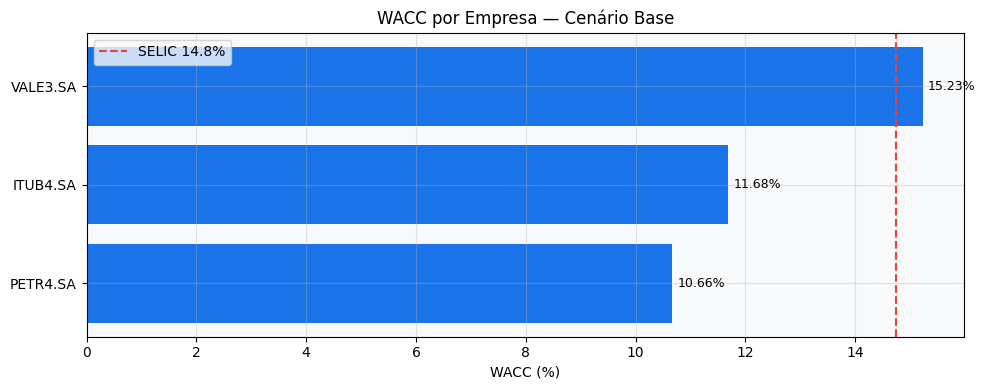

'/tmp/figs_relatorio/01_wacc.png'

In [83]:
# =============================================================================
# CÉLULA 6 — WACC AUTOMÁTICO POR EMPRESA (CAPM + spread de crédito)
# =============================================================================

def calcular_wacc_empresa(ticker, fundamentos, selic, ipca, cenario):
    """
    WACC = Ke * E/(D+E) + Kd*(1-t) * D/(D+E)
    Ke via CAPM: Ke = Rf + β * (Rm - Rf)
      Rf  = SELIC real ≈ SELIC - IPCA
      Rm  = retorno esperado do mercado (Rf + prêmio de risco país)
    Kd  = SELIC + spread setorial
    """
    row  = fundamentos.loc[ticker] if ticker in fundamentos.index else pd.Series(dtype=float)
    beta = float(row.get("beta", 1.0) or 1.0)
    setor = SETORES.get(ticker, "Outro")

    # Premios por cenário
    premio_risco = {"Bull": 0.055, "Base": 0.065, "Bear": 0.080}[cenario]
    spread_kd    = {"Bull": 0.010, "Base": 0.015, "Bear": 0.025}[cenario]

    # Custo do equity (CAPM)
    Rf = max(selic - ipca, 0.02)          # taxa real livre de risco
    Rm = Rf + premio_risco                 # retorno esperado mercado
    Ke = Rf + beta * (Rm - Rf)

    # Custo da dívida
    spread_setor = {"Utilities": 0.005, "Financeiro": 0.010,
                    "Tecnologia": 0.008}.get(setor, 0.012)
    Kd = selic + spread_kd + spread_setor
    t  = 0.34   # alíquota IR+CSLL simplificada

    # Estrutura de capital
    debt   = float(row.get("totalDebt",   0) or 0)
    cap    = float(row.get("marketCap",   1) or 1)
    E_pct  = cap  / max(cap + debt, 1)
    D_pct  = debt / max(cap + debt, 1)

    wacc = Ke * E_pct + Kd * (1 - t) * D_pct
    return {"wacc": round(wacc, 4), "Ke": round(Ke, 4),
            "Kd": round(Kd, 4), "beta": round(beta, 3),
            "E_pct": round(E_pct, 3), "D_pct": round(D_pct, 3)}


WACC_POR_ATIVO = {t: calcular_wacc_empresa(t, FUNDAMENTOS, SELIC_ATUAL, IPCA_12M, CENARIO)
                  for t in TICKERS}

df_wacc = pd.DataFrame(WACC_POR_ATIVO).T
print("\n📐 WACC Automático por Empresa (CAPM + estrutura de capital):")
print(df_wacc.round(4).to_string())

# Gráfico WACC
fig, ax = plt.subplots(figsize=(10, 4))
waccs = df_wacc["wacc"].sort_values()
bars = ax.barh(waccs.index, waccs.values * 100, color=CORES["azul"])
ax.axvline(SELIC_ATUAL * 100, color=CORES["vermelho"], lw=1.5, ls="--", label=f"SELIC {SELIC_ATUAL:.1%}")
ax.set_xlabel("WACC (%)")
ax.set_title(f"WACC por Empresa — Cenário {CENARIO}")
ax.legend()
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.2f}%", va="center", fontsize=9)
plt.tight_layout()
salvar_fig("01_wacc")

## CÉLULA 7 — ESTATÍSTICAS E GRÁFICOS DE RETORNO


📊 Estatísticas de Retorno:
Ticker                  ITUB4.SA  PETR4.SA  VALE3.SA
Retorno Anual (%)         21.890    44.420     9.390
Volatilidade Anual (%)    25.000    31.760    29.450
Sharpe                     0.325     0.965    -0.148
Assimetria                -1.000    -0.266     0.372
Curtose                   14.503     2.460     2.191
Max Drawdown (%)         -35.870   -39.100   -41.340
Dias Positivos (%)        51.300    54.000    49.100


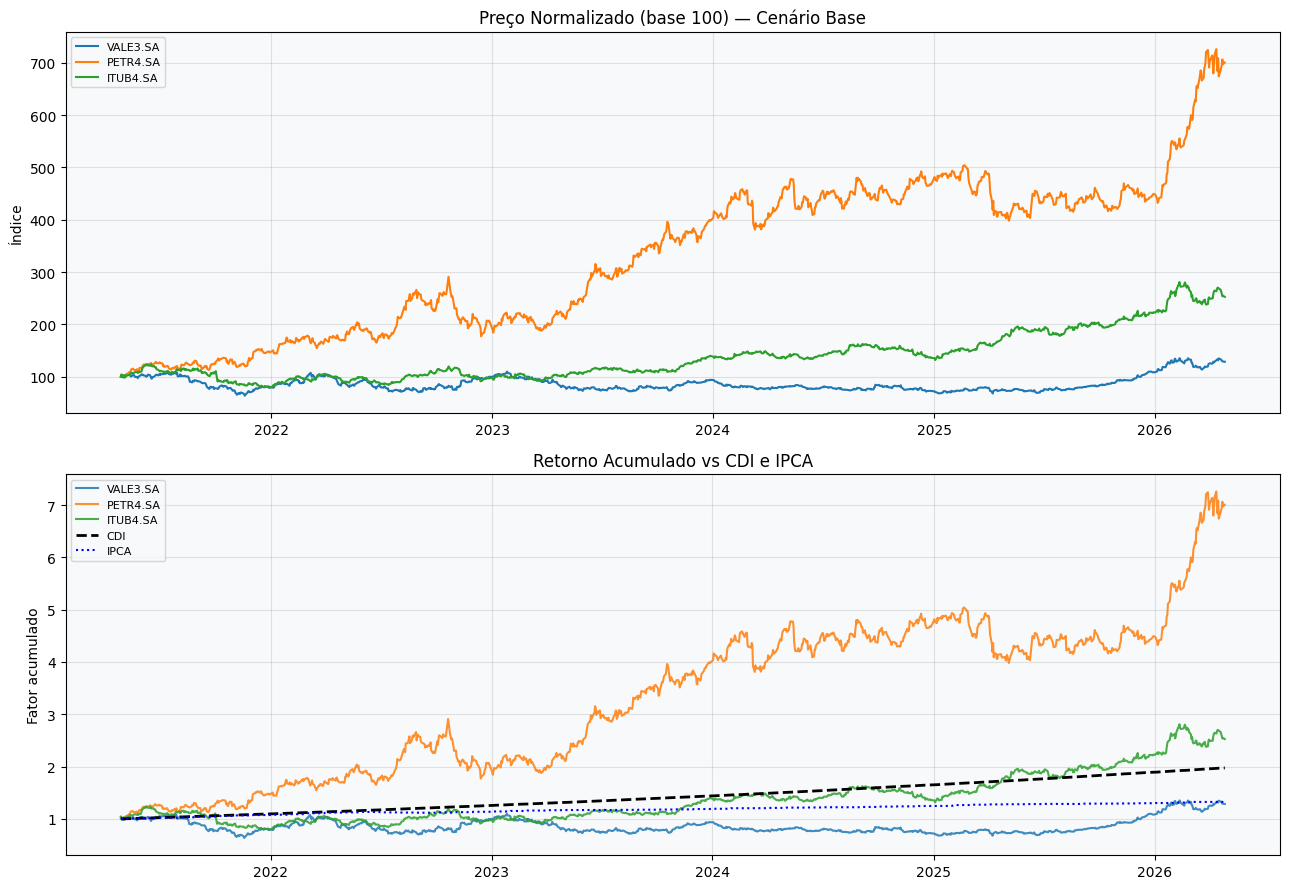

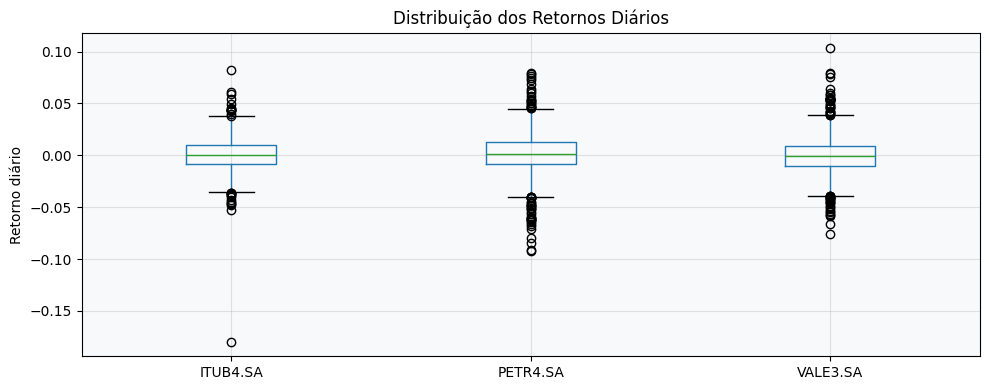

'/tmp/figs_relatorio/03_boxplot_retornos.png'

In [84]:
# =============================================================================
# CÉLULA 7 — ESTATÍSTICAS E GRÁFICOS DE RETORNO
# =============================================================================

def stats_retornos(rets, cdi):
    mu  = rets.mean() * TRADING_DAYS
    vol = rets.std()  * np.sqrt(TRADING_DAYS)
    rf  = cdi.mean()  * TRADING_DAYS
    sr  = (mu - rf) / vol.replace(0, np.nan)
    sk  = rets.skew()
    ku  = rets.kurt()
    acum = (1 + rets).cumprod()
    mdd = ((acum / acum.cummax()) - 1).min()
    pos = (rets > 0).mean() * 100
    return pd.DataFrame({
        "Retorno Anual (%)":      (mu * 100).round(2),
        "Volatilidade Anual (%)": (vol * 100).round(2),
        "Sharpe":                 sr.round(3),
        "Assimetria":             sk.round(3),
        "Curtose":                ku.round(3),
        "Max Drawdown (%)":       (mdd * 100).round(2),
        "Dias Positivos (%)":     pos.round(1),
    })

STATS = stats_retornos(RETORNOS, CDI_SERIE)
print("\n📊 Estatísticas de Retorno:")
print(STATS.T.to_string())

# --- Gráfico preço normalizado ---
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
norm = PRECOS / PRECOS.iloc[0] * 100
for t in TICKERS:
    if t in norm.columns:
        axes[0].plot(norm.index, norm[t], label=t)
axes[0].set_title(f"Preço Normalizado (base 100) — Cenário {CENARIO}", fontsize=12)
axes[0].legend(loc="upper left", fontsize=8)
axes[0].set_ylabel("Índice")

# Retorno acumulado vs CDI e IPCA
cdi_acum  = (1 + CDI_SERIE).cumprod()
for t in TICKERS:
    if t in RETORNOS.columns:
        axes[1].plot((1 + RETORNOS[t]).cumprod(), label=t, alpha=0.85)

axes[1].plot(cdi_acum, "k--", lw=2, label="CDI")

# IPCA acumulado
if "IPCA_mensal" in MACRO_RAW.columns:
    ipca_m = MACRO_RAW["IPCA_mensal"].dropna() / 100
    ipca_acum = (1 + ipca_m).cumprod().reindex(RETORNOS.index, method="ffill")
    if not ipca_acum.isnull().all():
        ipca_acum = ipca_acum / ipca_acum.iloc[0]
        axes[1].plot(ipca_acum, "b:", lw=1.5, label="IPCA")

axes[1].set_title("Retorno Acumulado vs CDI e IPCA", fontsize=12)
axes[1].legend(loc="upper left", fontsize=8)
axes[1].set_ylabel("Fator acumulado")
plt.tight_layout()
salvar_fig("02_retorno_acumulado")

# --- Boxplot retornos ---
fig, ax = plt.subplots(figsize=(10, 4))
RETORNOS.boxplot(ax=ax)
ax.set_title("Distribuição dos Retornos Diários")
ax.set_ylabel("Retorno diário")
plt.tight_layout()
salvar_fig("03_boxplot_retornos")

## CÉLULA 8 — SCORE FUNDAMENTAL (0–100)

Decomposição do Score Fundamental:
          Rentabilidade /30  Valuation /25  Crescimento /20  Risco /15  Solidez /10  Score Final
VALE3.SA               19.3           16.4              0.3       12.0          6.3         54.3
PETR4.SA               30.0           23.8              3.3        4.1          4.7         65.9
ITUB4.SA               24.0           18.1              8.7        7.8          1.9         51.4


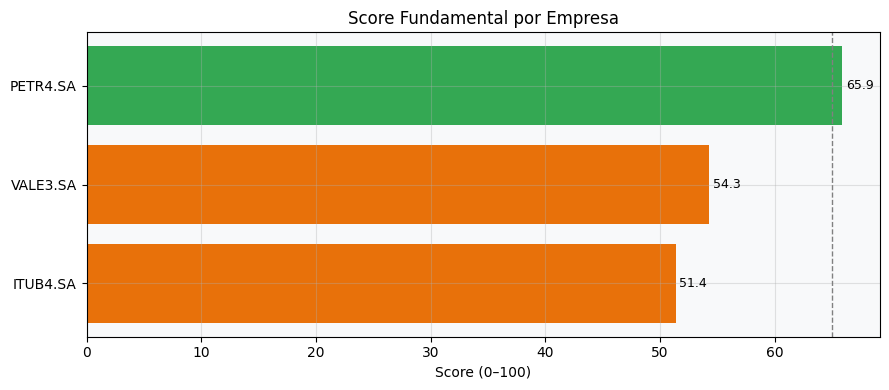

PETR4.SA    65.9
VALE3.SA    54.3
ITUB4.SA    51.4


In [85]:
# =============================================================================
# CÉLULA 8 — SCORE FUNDAMENTAL (0–100)
# =============================================================================

def calcular_score_fundamental(fundamentos, retornos_stats):
    """
    Score 0-100 com 5 blocos de pesos fixos.
    Cada bloco é normalizado em [0,1] internamente antes de receber seu peso,
    garantindo teto real = 100 (antes de penalidades).

    Pesos: Rentabilidade 30 | Valuation 25 | Crescimento 20 | Risco 15 | Solidez 10
    """
    scores = {}
    detalhes = {}

    for t, row in fundamentos.iterrows():
        roe_min = limite(t, "roe_min")
        mg_min  = limite(t, "margem_min")
        dl_max  = limite(t, "dl_ebitda_max")

        def get(campo, default=0.0):
            v = row.get(campo, default)
            try:
                return float(v) if v is not None and str(v) not in ("nan","None") else float(default)
            except Exception:
                return float(default)

        def clamp01(x):
            return max(0.0, min(1.0, float(x)))

        # ── BLOCO 1: Rentabilidade — peso 30 ─────────────────────────────────
        roe    = get("returnOnEquity")
        roa    = get("returnOnAssets")
        mg_liq = get("profitMargins")

        b1_roe = clamp01(roe / max(roe_min, 0.01))
        b1_roa = clamp01(roa / 0.08)
        b1_mg  = clamp01(mg_liq / max(mg_min, 0.01))
        bloco_rentabilidade = clamp01(b1_roe * 0.50 + b1_roa * 0.25 + b1_mg * 0.25) * 30

        # ── BLOCO 2: Valuation — peso 25 ─────────────────────────────────────
        pl    = row.get("trailingPE")
        pvp   = row.get("priceToBook")
        ev_eb = row.get("enterpriseToEbitda")
        dy    = get("dividendYield")

        try:
            b2_pl = clamp01((40 - float(pl)) / 30) if pl and 0 < float(pl) < 60 else 0.5
        except Exception:
            b2_pl = 0.5
        try:
            b2_pvp = clamp01((4 - float(pvp)) / 3) if pvp and 0 < float(pvp) < 10 else 0.5
        except Exception:
            b2_pvp = 0.5
        try:
            b2_ev = clamp01((16 - float(ev_eb)) / 10) if ev_eb and 0 < float(ev_eb) < 25 else 0.5
        except Exception:
            b2_ev = 0.5
        b2_dy = clamp01(dy / 0.06)

        bloco_valuation = clamp01(b2_pl * 0.35 + b2_pvp * 0.30 + b2_ev * 0.25 + b2_dy * 0.10) * 25

        # ── BLOCO 3: Crescimento — peso 20 ───────────────────────────────────
        rev_g = get("revenueGrowth")
        ear_g = get("earningsGrowth")

        b3_rev = clamp01(max(rev_g, 0) / 0.15)
        b3_ear = clamp01(max(ear_g, 0) / 0.20)
        bloco_crescimento = clamp01(b3_rev * 0.50 + b3_ear * 0.50) * 20

        # ── BLOCO 4: Risco de mercado — peso 15 ──────────────────────────────
        beta      = get("beta", 1.0)
        vol_anual = (retornos_stats.loc[t, "Volatilidade Anual (%)"] / 100
                     if t in retornos_stats.index else 0.30)

        b4_beta = clamp01(1 - abs(beta - 1) / 1.0)
        b4_vol  = clamp01((0.50 - vol_anual) / 0.30)
        bloco_risco = clamp01(b4_beta * 0.55 + b4_vol * 0.45) * 15

        # ── BLOCO 5: Solidez financeira — peso 10 ────────────────────────────
        debt  = get("totalDebt")
        cash  = get("totalCash")
        ebitda = get("ebitda", 1.0) or 1.0
        liq_c  = get("currentRatio", 1.0)
        liq_r  = get("quickRatio",   0.5)

        dl_eb = max(debt - cash, 0) / max(abs(ebitda), 1)
        b5_dl  = clamp01(1 - dl_eb / dl_max)
        b5_liq = clamp01(liq_c / 2.5)
        b5_liqr= clamp01(liq_r / 1.5)
        bloco_solidez = clamp01(b5_dl * 0.50 + b5_liq * 0.30 + b5_liqr * 0.20) * 10

        # ── Score bruto: máximo exato = 100 ──────────────────────────────────
        s = bloco_rentabilidade + bloco_valuation + bloco_crescimento \
            + bloco_risco + bloco_solidez

        # ── Penalidades multiplicativas (só em violações claras) ──────────────
        if dl_eb > dl_max * 1.10:
            s *= 0.85
        if mg_liq < mg_min * 0.40:
            s *= 0.90

        final = max(0.0, min(100.0, s))
        scores[t] = round(final, 1)
        detalhes[t] = {
            "Rentabilidade /30": round(bloco_rentabilidade, 1),
            "Valuation /25":     round(bloco_valuation,     1),
            "Crescimento /20":   round(bloco_crescimento,   1),
            "Risco /15":         round(bloco_risco,         1),
            "Solidez /10":       round(bloco_solidez,       1),
            "Score Final":       round(final,               1),
        }

    print("Decomposição do Score Fundamental:")
    print(pd.DataFrame(detalhes).T.to_string())

    return pd.Series(scores, name="Score_Fundamental")

SCORE_FUND = calcular_score_fundamental(FUNDAMENTOS, STATS)

fig, ax = plt.subplots(figsize=(9, max(4, len(TICKERS) * 0.55 + 1)))
sf_sorted = SCORE_FUND.sort_values()
bars = ax.barh(sf_sorted.index, sf_sorted.values,
               color=[CORES["verde"] if v >= 65 else CORES["laranja"] if v >= 50
                      else CORES["vermelho"] for v in sf_sorted.values])
ax.set_xlabel("Score (0–100)")
ax.set_title("Score Fundamental por Empresa")
ax.axvline(65, color="gray", ls="--", lw=1)
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}", va="center", fontsize=9)
plt.tight_layout()
salvar_fig("04_score_fundamental")
print(SCORE_FUND.sort_values(ascending=False).to_string())

## CÉLULA 9 — CREDIT SCORE (0–100) + RATING SINTÉTICO


🏦 Credit Score e Rating Sintético:
          Credit_Score Rating_Sintetico  DL_EBITDA  Liquidez_Corrente  Liquidez_Rapida  Caixa_Receita
ticker                                                                                               
VALE3.SA          69.5                A       0.97               1.15             0.72          0.195
PETR4.SA          53.9               BB       1.60               0.71             0.44          0.102
ITUB4.SA         100.0              AAA        NaN                NaN              NaN          3.473


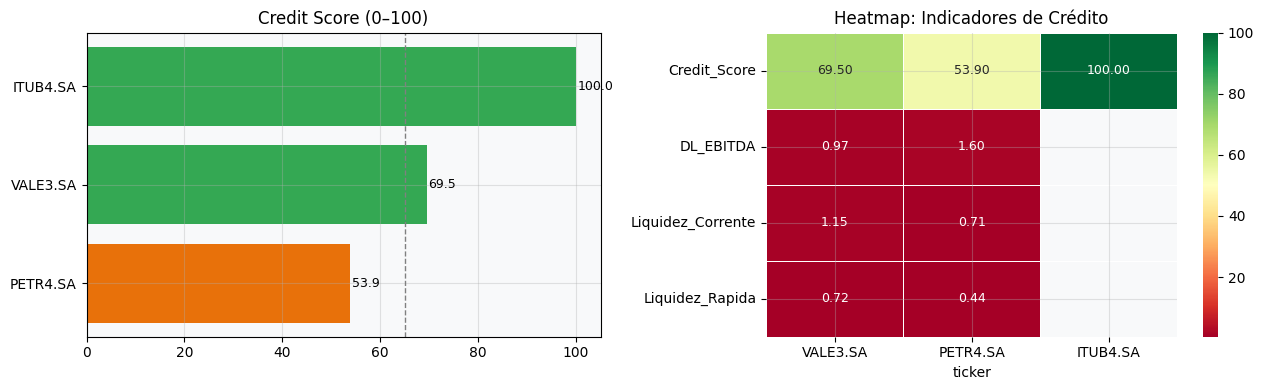

'/tmp/figs_relatorio/05_credit_score.png'

In [86]:
# =============================================================================
# CÉLULA 9 — CREDIT SCORE (0–100) + RATING SINTÉTICO
# =============================================================================

def calcular_credit_score(fundamentos):
    resultados = []
    for t, row in fundamentos.iterrows():
        debt   = float(row.get("totalDebt",    0) or 0)
        cash   = float(row.get("totalCash",    0) or 0)
        ebitda = float(row.get("ebitda",       1) or 1)
        receita= float(row.get("totalRevenue", 1) or 1)
        liq_c  = float(row.get("currentRatio", 1) or 1)
        liq_r  = float(row.get("quickRatio",   0) or 0)
        mg_op  = float(row.get("operatingMargins", 0) or 0)

        dl_eb  = max(debt - cash, 0) / max(abs(ebitda), 1)
        dl_max = limite(t, "dl_ebitda_max")
        caixa_r = cash / max(receita, 1)
        mg_min  = limite(t, "margem_min")

        s = 0.0
        s += max(0, 1 - dl_eb / dl_max) * 40    # Alavancagem
        s += min(liq_c / 3.0, 1.0) * 20          # Liquidez corrente
        s += min(liq_r / 2.0, 1.0) * 15          # Liquidez rápida
        s += min(caixa_r / 0.15, 1.0) * 15       # Caixa/Receita
        s += min(max(mg_op, 0) / max(mg_min, 0.01), 1.0) * 10  # Margem

        s = max(0, min(100, s))
        if   s >= 85: rating = "AAA"
        elif s >= 75: rating = "AA"
        elif s >= 65: rating = "A"
        elif s >= 55: rating = "BBB"
        elif s >= 45: rating = "BB"
        elif s >= 35: rating = "B"
        else:         rating = "CCC"

        resultados.append({
            "ticker": t, "Credit_Score": round(s, 1),
            "Rating_Sintetico": rating, "DL_EBITDA": round(dl_eb, 2),
            "Liquidez_Corrente": round(liq_c, 2),
            "Liquidez_Rapida":   round(liq_r, 2),
            "Caixa_Receita":     round(caixa_r, 3),
        })
    return pd.DataFrame(resultados).set_index("ticker")


CREDIT = calcular_credit_score(FUNDAMENTOS)
print("\n🏦 Credit Score e Rating Sintético:")
print(CREDIT.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, max(4, len(TICKERS) * 0.7 + 1)))

cs_sorted = CREDIT["Credit_Score"].sort_values()
cor_credit = [CORES["verde"] if v >= 65 else CORES["laranja"] if v >= 50
              else CORES["vermelho"] for v in cs_sorted.values]
axes[0].barh(cs_sorted.index, cs_sorted.values, color=cor_credit)
axes[0].set_title("Credit Score (0–100)")
axes[0].axvline(65, color="gray", ls="--", lw=1)
for i, v in enumerate(cs_sorted.values):
    axes[0].text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=9)

heat_data = CREDIT[["Credit_Score","DL_EBITDA","Liquidez_Corrente","Liquidez_Rapida"]].astype(float)
sns.heatmap(heat_data.T, annot=True, fmt=".2f", cmap="RdYlGn",
            ax=axes[1], linewidths=0.5, annot_kws={"size": 9})
axes[1].set_title("Heatmap: Indicadores de Crédito")
plt.tight_layout()
salvar_fig("05_credit_score")

## CÉLULA 10 — ANÁLISE COPOM + SENTIMENTO HAWKISH/DOVISH

⏳ Buscando atas do COPOM e carregando modelo de sentimento …


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

   ✅ Modelo de sentimento carregado.
[INFO] 30 atas listadas. Aplicando limite=30.
[INFO] Processadas 10 atas …
[INFO] Processadas 20 atas …
[INFO] Processadas 30 atas …

📜 COPOM — Ata Nº 277
   Data publicação   : 2026-03-24
   Índice H–D        : +43
   Sentimento (BERT) : 2.20 estrelas
   Perfil COPOM      : HAWKISH

   A última ata do COPOM apresenta viés predominantemente hawkish. O Comitê demonstra preocupação com pressões inflacionárias e sinaliza cautela na condução da política monetária, mantendo ou elevando a taxa Selic para ancorar as expectativas de inflação. Esse ambiente tende a pressionar o custo de capital das empresas e comprimir múltiplos de valuation.

[TOP 5 — MAIS HAWKISH]
dataPublicacao  nroReuniao  hd_index  sent_stars_mean                                        titulo
    2025-02-04         268       113              2.6            268ª Reunião - 28-29 janeiro, 2025
    2024-12-17         267       107              2.2           267ª Reunião - 10-11 dezembro, 20

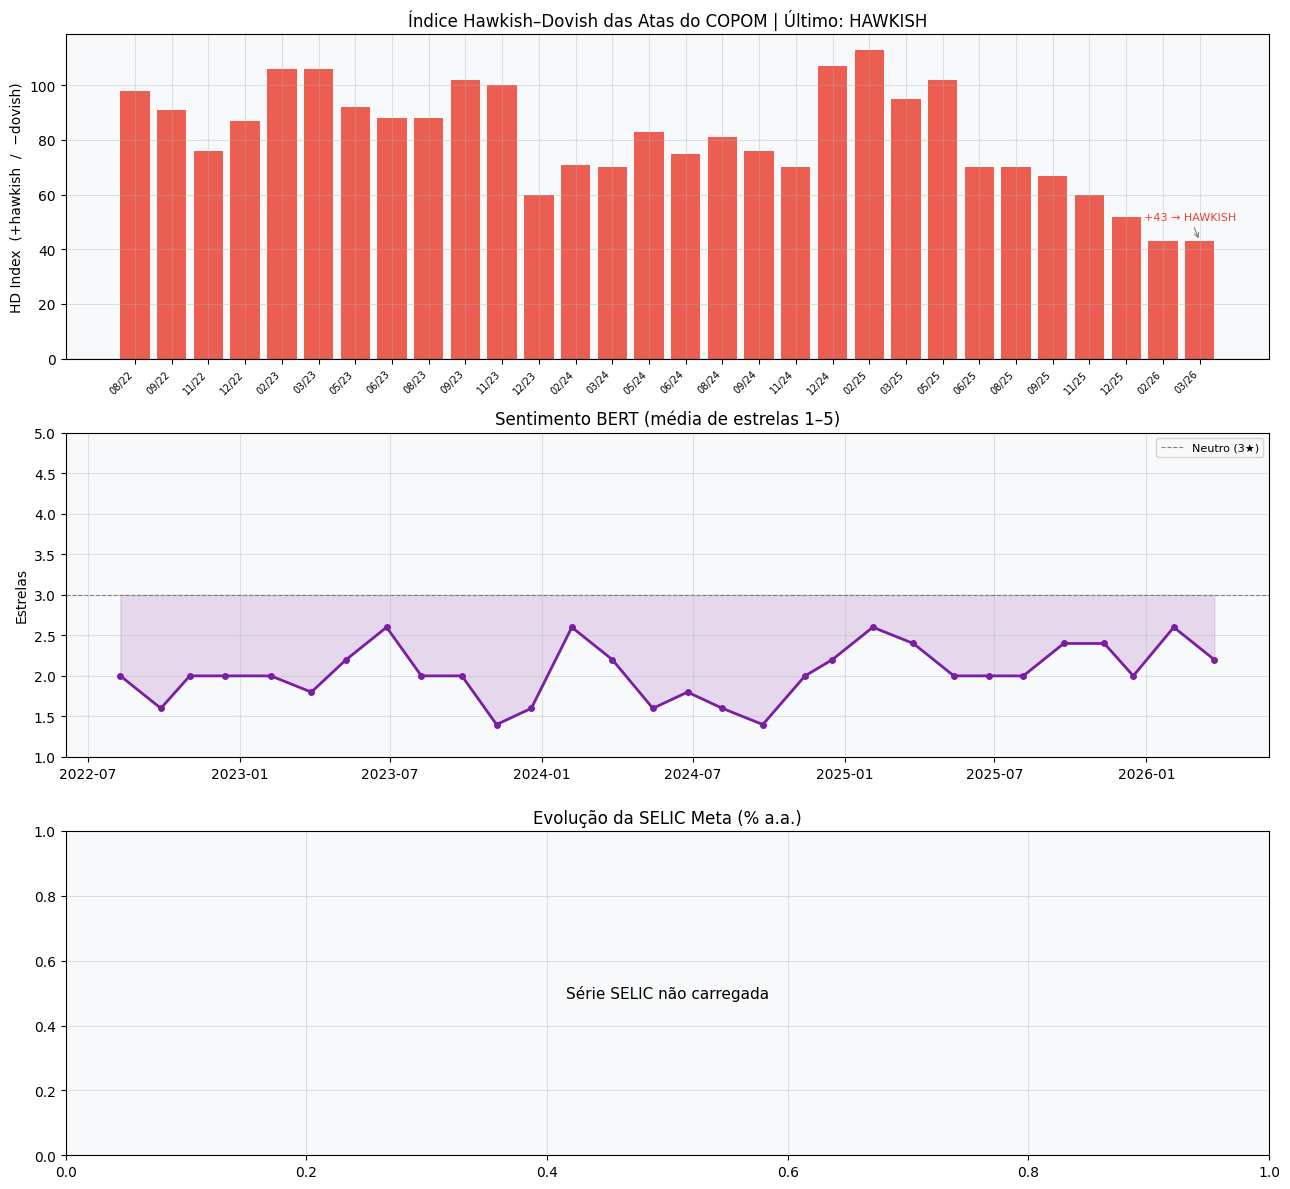

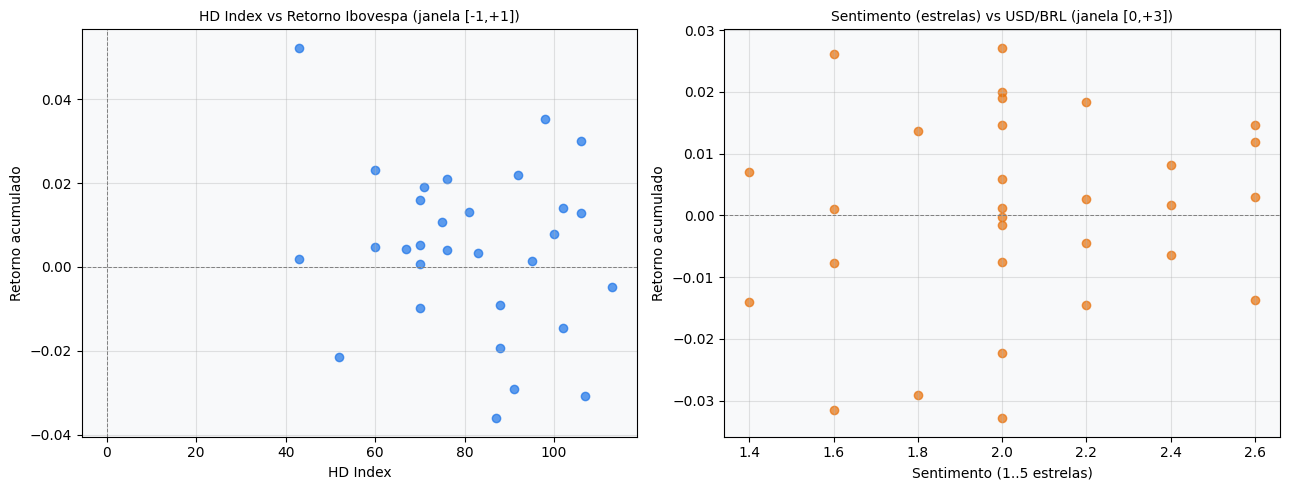

In [87]:
# =============================================================================
# CÉLULA 10 — ANÁLISE COPOM + SENTIMENTO HAWKISH/DOVISH (via Transformers)
# =============================================================================
# Referência: código do Prof. João Luiz Chela (aula sentimento COPOM)
# API BCB: https://www.bcb.gov.br/api/servico/sitebcb/copom/atas
# Modelo NLP: nlptown/bert-base-multilingual-uncased-sentiment (1..5 estrelas)
# =============================================================================

print("⏳ Buscando atas do COPOM e carregando modelo de sentimento …")

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords as _sw
STOPWORDS_PT = set(_sw.words("portuguese"))

from transformers import pipeline as _hf_pipeline

# ── Modelo multilíngue de sentimento (funciona bem em PT) ─────────────────────
try:
    _sent_pipe = _hf_pipeline(
        "sentiment-analysis",
        model="nlptown/bert-base-multilingual-uncased-sentiment"
    )
    MODELO_SENT_OK = True
    print("   ✅ Modelo de sentimento carregado.")
except Exception as _e:
    _sent_pipe     = None
    MODELO_SENT_OK = False
    print(f"   ⚠️  Modelo de sentimento indisponível: {_e}")

# ── Vocabulários HD ───────────────────────────────────────────────────────────
HAWKISH_WORDS = [
    "inflação","inflacionária","pressão","pressões","risco","riscos","aperto",
    "elevação","elevar","persistência","desancoragem","desancorar","vigilante",
    "cautela","prudência","restritiva","restrição","aceleração","alta",
    "contração","contrativos","adversos","deterioração","incerteza",
]
DOVISH_WORDS = [
    "redução","reduzir","flexibilização","flexibilizar","estímulo","estimular",
    "arrefecimento","moderação","desinflação","desinflacionário","acomodatícia",
    "acomodativa","suavização","suavizar","queda","recuo","convergência","benignos",
]

BASE_LIST    = "https://www.bcb.gov.br/api/servico/sitebcb/copom/atas"
BASE_DETAILS = "https://www.bcb.gov.br/api/servico/sitebcb/copom/atas_detalhes"


# ── Funções auxiliares ────────────────────────────────────────────────────────

def _get_json_bcb(url, params=None, timeout=30):
    r = requests.get(url, params=params, timeout=timeout)
    r.raise_for_status()
    return r.json()


def limpar_texto_pt(texto: str) -> str:
    if not isinstance(texto, str) or not texto.strip():
        return ""
    texto = re.sub(r"<[^>]+>", " ", texto)
    texto = texto.replace("\u00a0", " ").lower()
    texto = re.sub(r"[^a-zà-ú\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    tokens = [t for t in texto.split() if t not in STOPWORDS_PT and len(t) > 2]
    return " ".join(tokens)


def indice_hawkish_dovish(texto_limpo: str) -> int:
    h = sum(texto_limpo.count(w) for w in HAWKISH_WORDS)
    d = sum(texto_limpo.count(w) for w in DOVISH_WORDS)
    return int(h - d)


def sentimento_multilingue(texto: str, max_chars: int = 2000) -> dict:
    """
    Usa o modelo BERT multilíngue para estimar sentimento do texto.
    Divide em chunks de 400 chars e faz média das estrelas (1..5).
    Retorna dict com 'stars_mean' e 'n_chunks'.
    """
    if not texto or not MODELO_SENT_OK:
        return {"stars_mean": np.nan, "n_chunks": 0}
    texto = texto[:max_chars]
    chunk_size = 400
    chunks = [texto[i:i+chunk_size] for i in range(0, len(texto), chunk_size)]
    stars = []
    for ch in chunks:
        try:
            out    = _sent_pipe(ch)[0]   # ex: {'label': '4 stars', 'score': 0.51}
            nstars = int(out["label"].split()[0])
            stars.append(nstars)
        except Exception:
            pass
    if not stars:
        return {"stars_mean": np.nan, "n_chunks": 0}
    return {"stars_mean": float(np.mean(stars)), "n_chunks": len(stars)}


def listar_atas_pagina(quantidade=100, pagina=1):
    data     = _get_json_bcb(BASE_LIST, params={"quantidade": quantidade, "pagina": pagina})
    conteudo = data.get("conteudo", [])
    return pd.DataFrame(conteudo)


def listar_todas_atas(max_paginas=10, por_pagina=30, pausa=0.15):
    """Navega pelas páginas da API até repetir ou esgotar."""
    dfs, primeiros = [], []
    for p in range(1, max_paginas + 1):
        try:
            dfp = listar_atas_pagina(quantidade=por_pagina, pagina=p)
        except Exception as e:
            print(f"  ⚠️  Página {p} falhou: {e}")
            break
        if dfp.empty:
            break
        first_id = dfp.iloc[0].get("nroReuniao", None)
        if first_id in primeiros:
            break
        primeiros.append(first_id)
        dfs.append(dfp)
        time.sleep(pausa)
    if not dfs:
        return pd.DataFrame()
    df = pd.concat(dfs, ignore_index=True)
    if "nroReuniao" in df.columns:
        df = df.drop_duplicates(subset=["nroReuniao"]).reset_index(drop=True)
    return df


def detalhes_ata(nro_reuniao: int) -> dict:
    try:
        data     = _get_json_bcb(BASE_DETAILS, params={"nro_reuniao": int(nro_reuniao)})
        conteudo = data.get("conteudo", [])
        return conteudo[0] if conteudo else {}
    except Exception:
        return {}


# ── Coleta e processamento ────────────────────────────────────────────────────

def construir_base_atas(limite_atas=30, verbose=True):
    df_list = listar_todas_atas(max_paginas=10, por_pagina=30)
    if df_list.empty:
        print("  ⚠️  Nenhuma ata obtida via API.")
        return pd.DataFrame()

    if verbose:
        print(f"[INFO] {len(df_list)} atas listadas. Aplicando limite={limite_atas}.")
    df_list = df_list.head(int(limite_atas)).copy()

    rows = []
    for i, row_l in df_list.iterrows():
        nro = int(row_l["nroReuniao"])
        det = detalhes_ata(nro)
        if not det:
            continue

        texto_bruto = (det.get("textoAta") or "").strip()
        texto_limpo = limpar_texto_pt(texto_bruto) if texto_bruto else ""

        hd   = indice_hawkish_dovish(texto_limpo) if texto_limpo else np.nan
        sent = sentimento_multilingue(texto_limpo) if texto_limpo else {"stars_mean": np.nan, "n_chunks": 0}

        rows.append({
            "nroReuniao":      nro,
            "titulo":          det.get("titulo", ""),
            "dataReferencia":  det.get("dataReferencia"),
            "dataPublicacao":  det.get("dataPublicacao"),
            "texto_bruto_len": len(texto_bruto),
            "hd_index":        hd,
            "sent_stars_mean": sent["stars_mean"],
            "sent_n_chunks":   sent["n_chunks"],
            "texto_limpo":     texto_limpo,
        })

        if verbose and (i + 1) % 10 == 0:
            print(f"[INFO] Processadas {i + 1} atas …")
        time.sleep(0.12)

    df = pd.DataFrame(rows)
    for col in ["dataReferencia", "dataPublicacao"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df.sort_values("dataPublicacao").reset_index(drop=True)


# ── Execução principal ────────────────────────────────────────────────────────

DF_COPOM = construir_base_atas(limite_atas=30, verbose=True)

# ── Variáveis globais para uso nas demais células ─────────────────────────────
ULTIMA_ATA      = {}
ULTIMO_HD       = np.nan
ULTIMA_SENT     = np.nan
PERFIL_COPOM    = "INDISPONÍVEL"
DESCRICAO_COPOM = "Dados do COPOM não disponíveis no momento da análise."

if not DF_COPOM.empty:

    # Última ata com dado de HD
    ultima        = DF_COPOM.dropna(subset=["hd_index"]).iloc[-1]
    ULTIMA_ATA    = ultima.to_dict()
    ULTIMO_HD     = float(ultima["hd_index"])
    ULTIMA_SENT   = float(ultima.get("sent_stars_mean", np.nan) or np.nan)

    # Perfil HD
    if ULTIMO_HD > 5:
        PERFIL_COPOM    = "HAWKISH"
        DESCRICAO_COPOM = (
            "A última ata do COPOM apresenta viés predominantemente hawkish. "
            "O Comitê demonstra preocupação com pressões inflacionárias e sinaliza "
            "cautela na condução da política monetária, mantendo ou elevando a taxa Selic "
            "para ancorar as expectativas de inflação. Esse ambiente tende a pressionar "
            "o custo de capital das empresas e comprimir múltiplos de valuation."
        )
    elif ULTIMO_HD < -5:
        PERFIL_COPOM    = "DOVISH"
        DESCRICAO_COPOM = (
            "A última ata do COPOM apresenta viés predominantemente dovish. "
            "O Comitê sinaliza espaço para flexibilização monetária, com perspectiva "
            "de redução gradual da taxa Selic à medida que a inflação converge para a meta. "
            "Esse ambiente tende a reduzir o custo de capital e expandir múltiplos de equity."
        )
    else:
        PERFIL_COPOM    = "NEUTRO"
        DESCRICAO_COPOM = (
            "A última ata do COPOM apresenta tom neutro/equilibrado. "
            "O Comitê avalia riscos em ambas as direções e mantém postura de dependência "
            "de dados, sem sinalização clara de mudança de direção na política monetária."
        )

    sent_str = f"{ULTIMA_SENT:.2f} estrelas" if not np.isnan(ULTIMA_SENT) else "N/D"

    print(f"\n📜 COPOM — Ata Nº {int(ULTIMA_ATA.get('nroReuniao', 0))}")
    print(f"   Data publicação   : {str(ULTIMA_ATA.get('dataPublicacao', 'N/D'))[:10]}")
    print(f"   Índice H–D        : {ULTIMO_HD:+.0f}")
    print(f"   Sentimento (BERT) : {sent_str}")
    print(f"   Perfil COPOM      : {PERFIL_COPOM}")
    print(f"\n   {DESCRICAO_COPOM}")

    # ── Tabelas de análise ────────────────────────────────────────────────────
    print("\n[TOP 5 — MAIS HAWKISH]")
    top_hawk = DF_COPOM.sort_values("hd_index", ascending=False).head(5)
    print(top_hawk[["dataPublicacao","nroReuniao","hd_index","sent_stars_mean","titulo"]].to_string(index=False))

    print("\n[TOP 5 — MAIS DOVISH]")
    top_dove = DF_COPOM.sort_values("hd_index", ascending=True).head(5)
    print(top_dove[["dataPublicacao","nroReuniao","hd_index","sent_stars_mean","titulo"]].to_string(index=False))

    # ── Event Study: IBOVESPA + USD/BRL ao redor das atas ────────────────────
    _min_d = DF_COPOM["dataPublicacao"].min()
    _max_d = DF_COPOM["dataPublicacao"].max()
    _ini   = (_min_d - pd.Timedelta(days=10)).strftime("%Y-%m-%d")
    _fim   = (_max_d + pd.Timedelta(days=10)).strftime("%Y-%m-%d")

    try:
        _raw = yf.download(["^BVSP","BRL=X"], start=_ini, end=_fim, progress=False)
        if isinstance(_raw.columns, pd.MultiIndex):
            _px = _raw["Close"].dropna(how="all")
        else:
            _px = _raw.dropna(how="all")
        _ret_ev = _px.pct_change()

        def _retorno_janela(serie, data_evt, w0=-1, w1=1):
            if pd.isna(data_evt):
                return np.nan
            idx = serie.index
            pos = idx.searchsorted(pd.to_datetime(data_evt))
            pos = min(pos, len(idx) - 1)
            i0  = max(pos + w0, 0)
            i1  = min(pos + w1, len(idx) - 1)
            w   = serie.iloc[i0:i1+1].dropna()
            return float((1 + w).prod() - 1) if not w.empty else np.nan

        DF_EV = DF_COPOM.copy()
        for _col in ["^BVSP", "BRL=X"]:
            if _col in _ret_ev.columns:
                DF_EV[f"{_col}_ret_m1_p1"] = DF_EV["dataPublicacao"].apply(
                    lambda d: _retorno_janela(_ret_ev[_col], d, -1, +1))
                DF_EV[f"{_col}_ret_0_p3"]  = DF_EV["dataPublicacao"].apply(
                    lambda d: _retorno_janela(_ret_ev[_col], d,  0, +3))

        print("\n[EVENT STUDY — janelas de retorno ao redor da publicação da ata]")
        ev_cols = ["dataPublicacao","hd_index","sent_stars_mean"]
        ev_cols += [c for c in DF_EV.columns if "ret_" in c]
        print(DF_EV[ev_cols].tail(10).to_string(index=False))

        # Regressão HD → Retorno Ibovespa
        from sklearn.linear_model import LinearRegression as _LR
        def _regressao(df, ycol, xcols):
            d = df[[ycol] + xcols].dropna()
            if len(d) < 8:
                print(f"  [WARN] Poucas obs para regressão de {ycol} ({len(d)}).")
                return None
            m = _LR().fit(d[xcols].values, d[ycol].values)
            return {"n": len(d), "intercept": float(m.intercept_),
                    "coefs": dict(zip(xcols, m.coef_.tolist()))}

        _xcols = ["hd_index"] + (["sent_stars_mean"] if not DF_EV["sent_stars_mean"].isna().all() else [])
        print("\n[REGRESSÃO] IBOV janela [-1,+1]:")
        print(_regressao(DF_EV, "^BVSP_ret_m1_p1", _xcols))
        print("\n[REGRESSÃO] USD/BRL janela [-1,+1]:")
        print(_regressao(DF_EV, "BRL=X_ret_m1_p1", _xcols))

    except Exception as _ev_err:
        print(f"  ⚠️  Event study indisponível: {_ev_err}")
        DF_EV = DF_COPOM.copy()

    # ── GRÁFICOS ──────────────────────────────────────────────────────────────

    # G1: HD + Sentimento ao longo do tempo
    valid = DF_COPOM.dropna(subset=["hd_index"])
    fig, axes = plt.subplots(3, 1, figsize=(13, 12))

    cores_hd = [CORES["vermelho"] if v > 0 else CORES["azul"] for v in valid["hd_index"]]
    axes[0].bar(range(len(valid)), valid["hd_index"], color=cores_hd, alpha=0.85)
    axes[0].axhline(0, color="black", lw=0.8)
    axes[0].set_xticks(range(len(valid)))
    axes[0].set_xticklabels(
        [d.strftime("%m/%y") if pd.notna(d) else "" for d in valid["dataPublicacao"]],
        rotation=45, ha="right", fontsize=7)
    axes[0].set_title(f"Índice Hawkish–Dovish das Atas do COPOM | Último: {PERFIL_COPOM}", fontsize=12)
    axes[0].set_ylabel("HD Index  (+hawkish  /  −dovish)")
    if len(valid) > 0:
        axes[0].annotate(
            f"{ULTIMO_HD:+.0f} → {PERFIL_COPOM}",
            xy=(len(valid) - 1, ULTIMO_HD),
            xytext=(-40, 15), textcoords="offset points",
            fontsize=8,
            color=CORES["vermelho"] if ULTIMO_HD > 0 else CORES["azul"],
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
        )

    # G2: Sentimento BERT ao longo do tempo
    valid_sent = DF_COPOM.dropna(subset=["sent_stars_mean"])
    if not valid_sent.empty:
        axes[1].plot(valid_sent["dataPublicacao"], valid_sent["sent_stars_mean"],
                     color=CORES["roxo"], lw=2, marker="o", ms=4)
        axes[1].fill_between(valid_sent["dataPublicacao"], valid_sent["sent_stars_mean"],
                              3, alpha=0.15, color=CORES["roxo"])
        axes[1].axhline(3, color="gray", lw=0.8, ls="--", label="Neutro (3★)")
        axes[1].set_ylim(1, 5)
        axes[1].set_title("Sentimento BERT (média de estrelas 1–5)", fontsize=12)
        axes[1].set_ylabel("Estrelas")
        axes[1].legend(fontsize=8)
    else:
        xes[1].text(0.5, 0.5, "Sentimento BERT não disponível\n(modelo não carregado)",
             ha="center", va="center", transform=axes[1].transAxes, fontsize=11)
        axes[1].set_title("Sentimento BERT — indisponível", fontsize=12)

    # G3: SELIC meta (tratamento robusto)
    selic_plotada = False
    if "SELIC_meta" in MACRO_RAW.columns:
        selic_raw = MACRO_RAW["SELIC_meta"].copy()
        selic_raw.index = pd.to_datetime(selic_raw.index, errors="coerce")
        selic_raw = selic_raw[selic_raw.index.notna()]
        selic_raw = pd.to_numeric(
            selic_raw.astype(str).str.replace(",", "."), errors="coerce"
        ).dropna()
        if not selic_raw.empty:
            selic_m = selic_raw.resample("ME").last().dropna()
            if selic_m.empty:
                selic_m = selic_raw
            axes[2].plot(selic_m.index, selic_m.values,
                         color=CORES["laranja"], lw=2.2, label="SELIC Meta")
            axes[2].fill_between(selic_m.index, selic_m.values,
                                  alpha=0.18, color=CORES["laranja"])
            valor_atual = float(selic_m.iloc[-1])
            axes[2].axhline(valor_atual, color=CORES["vermelho"],
                            lw=1.2, ls="--", alpha=0.7,
                            label=f"Atual: {valor_atual:.2f}%")
            axes[2].legend(fontsize=9)
            axes[2].set_ylabel("% a.a.")
            axes[2].set_xlabel("Data")
            selic_plotada = True
            print(f"   📈 SELIC plotada: {len(selic_m)} pontos | "
                  f"atual={valor_atual:.2f}% em {selic_m.index[-1].strftime('%m/%Y')}")
    if not selic_plotada:
        axes[2].text(0.5, 0.5, "Série SELIC não carregada",
                     ha="center", va="center", transform=axes[2].transAxes, fontsize=11)
    axes[2].set_title("Evolução da SELIC Meta (% a.a.)", fontsize=12)

    plt.tight_layout()
    salvar_fig("06_copom_hd")

    # G4: Scatter HD vs IBOV
    if "DF_EV" in dir() and "^BVSP_ret_m1_p1" in DF_EV.columns:
        fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
        tmp1 = DF_EV[["hd_index","^BVSP_ret_m1_p1"]].dropna()
        if not tmp1.empty:
            axes2[0].scatter(tmp1["hd_index"], tmp1["^BVSP_ret_m1_p1"],
                             color=CORES["azul"], alpha=0.7)
            axes2[0].axhline(0, color="gray", lw=0.7, ls="--")
            axes2[0].axvline(0, color="gray", lw=0.7, ls="--")
            axes2[0].set_title("HD Index vs Retorno Ibovespa (janela [-1,+1])", fontsize=10)
            axes2[0].set_xlabel("HD Index")
            axes2[0].set_ylabel("Retorno acumulado")

        tmp2 = DF_EV[["sent_stars_mean","BRL=X_ret_0_p3"]].dropna() if "BRL=X_ret_0_p3" in DF_EV.columns else pd.DataFrame()
        if not tmp2.empty:
            axes2[1].scatter(tmp2["sent_stars_mean"], tmp2["BRL=X_ret_0_p3"],
                             color=CORES["laranja"], alpha=0.7)
            axes2[1].axhline(0, color="gray", lw=0.7, ls="--")
            axes2[1].set_title("Sentimento (estrelas) vs USD/BRL (janela [0,+3])", fontsize=10)
            axes2[1].set_xlabel("Sentimento (1..5 estrelas)")
            axes2[1].set_ylabel("Retorno acumulado")
        plt.tight_layout()
        salvar_fig("06b_copom_event_study")

else:
    print("⚠️  COPOM: nenhuma ata processada. Verifique conexão com a API do BCB.")

## CÉLULA 11 — VALUATION DCF MONTE CARLO

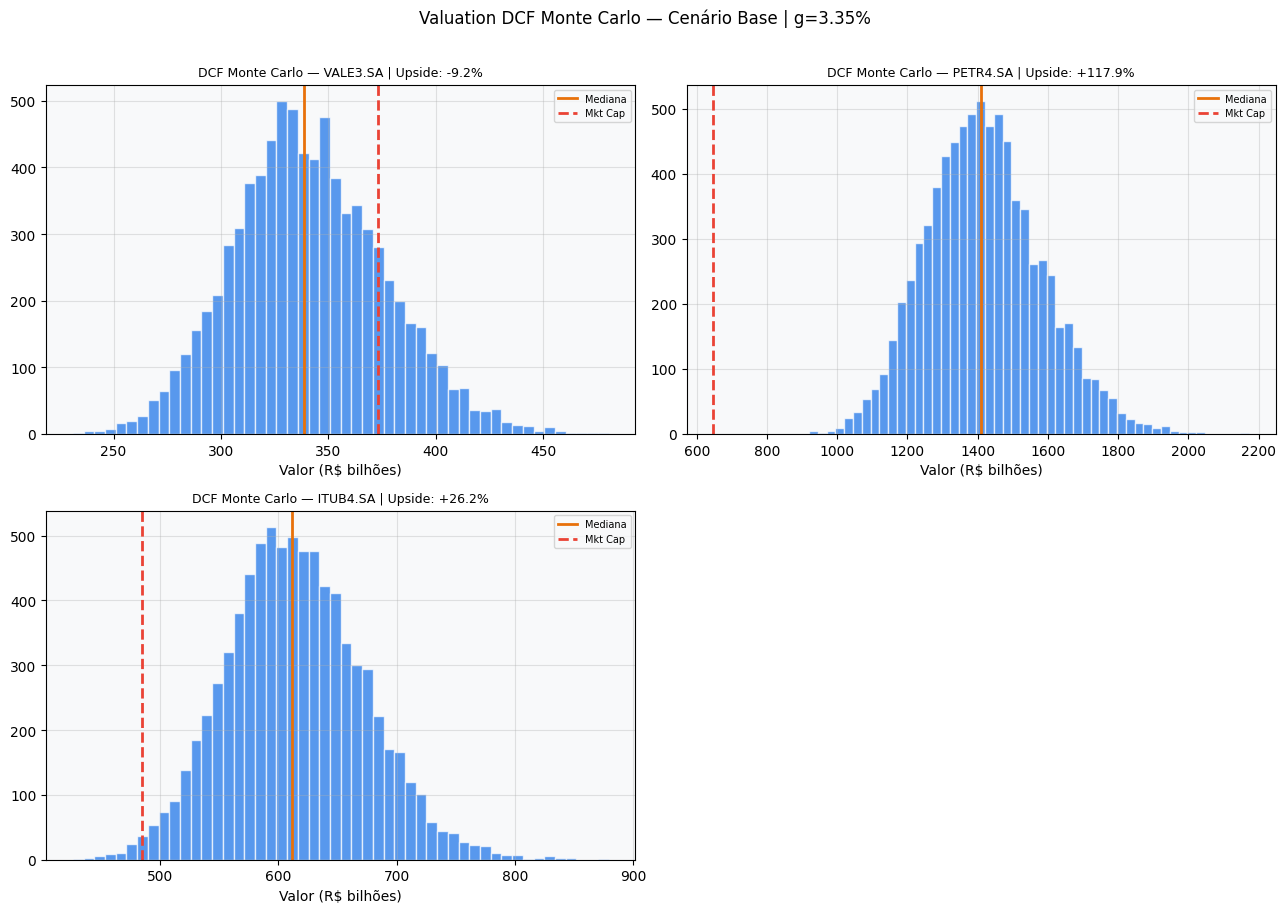


💰 Valuation DCF — Resumo:
          Média (R$B)  P10 (R$B)  Mediana (R$B)  P90 (R$B)  Mkt Cap (R$B)  Upside
VALE3.SA       341.02     297.32         338.80     387.96         373.22   -9.2%
PETR4.SA      1417.54    1212.99        1410.34    1634.83         647.24  117.9%
ITUB4.SA       614.69     542.89         612.04     689.64         484.83   26.2%


In [88]:
# =============================================================================
# CÉLULA 11 — VALUATION DCF MONTE CARLO
# =============================================================================

def monte_carlo_dcf(receita_inicial, crescimento_medio, crescimento_sd,
                    margem_media, margem_sd, wacc, g_perpetuidade,
                    anos=5, n_sim=8_000):
    valores = []
    for _ in range(n_sim):
        receita = receita_inicial
        fluxos  = []
        for _t in range(anos):
            g   = np.random.normal(crescimento_medio, crescimento_sd)
            mg  = np.random.normal(margem_media, margem_sd)
            receita *= (1 + g)
            fluxo    = receita * max(mg, 0) * 0.70
            fluxos.append(fluxo)
        vt    = fluxos[-1] * (1 + g_perpetuidade) / max(wacc - g_perpetuidade, 0.001)
        valor = sum(f / (1 + wacc) ** (i + 1) for i, f in enumerate(fluxos))
        valor += vt / (1 + wacc) ** anos
        valores.append(valor)
    return np.array(valores)


RESULTADOS_MC = {}

n_cols = 2
n_rows = math.ceil(len(TICKERS) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4.5 * n_rows))
axes = np.array(axes).flatten()

for idx, t in enumerate(TICKERS):
    info     = FUNDAMENTOS.loc[t] if t in FUNDAMENTOS.index else pd.Series(dtype=float)
    receita  = float(info.get("totalRevenue", 1e8) or 1e8)
    mg_op    = max(float(info.get("operatingMargins", 0.15) or 0.15), 0.04)
    rev_g    = float(info.get("revenueGrowth", 0.07) or 0.07)
    wacc_t   = WACC_POR_ATIVO[t]["wacc"]

    vals = monte_carlo_dcf(
        receita_inicial  = receita,
        crescimento_medio= max(rev_g, 0.02),
        crescimento_sd   = 0.04,
        margem_media     = mg_op,
        margem_sd        = 0.03,
        wacc             = wacc_t,
        g_perpetuidade   = G_PERPETUIDADE,
        n_sim            = 8_000,
    )
    mkt_cap = float(info.get("marketCap", np.nan) or np.nan)
    upside  = (np.median(vals) / mkt_cap - 1) if (mkt_cap and mkt_cap > 0) else np.nan
    RESULTADOS_MC[t] = {
        "media": np.mean(vals), "p10": np.percentile(vals, 10),
        "mediana": np.median(vals), "p90": np.percentile(vals, 90),
        "mkt_cap": mkt_cap, "upside": upside,
    }
    ax = axes[idx]
    ax.hist(vals / 1e9, bins=50, color=CORES["azul"], alpha=0.72, edgecolor="white")
    ax.axvline(np.median(vals) / 1e9, color=CORES["laranja"], lw=2, label=f"Mediana")
    if mkt_cap and not np.isnan(mkt_cap):
        ax.axvline(mkt_cap / 1e9, color=CORES["vermelho"], lw=2, ls="--", label="Mkt Cap")
    up_txt = f"{upside:+.1%}" if not np.isnan(upside) else "N/D"
    ax.set_title(f"DCF Monte Carlo — {t} | Upside: {up_txt}", fontsize=9)
    ax.set_xlabel("Valor (R$ bilhões)")
    ax.legend(fontsize=7)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Valuation DCF Monte Carlo — Cenário {CENARIO} | g={G_PERPETUIDADE:.2%}",
             fontsize=12, y=1.01)
plt.tight_layout()
salvar_fig("07_valuation_mc")

df_mc = pd.DataFrame(RESULTADOS_MC).T.apply(pd.to_numeric, errors="coerce")
df_mc[["media","p10","mediana","p90","mkt_cap"]] /= 1e9
df_mc.columns = ["Média (R$B)","P10 (R$B)","Mediana (R$B)","P90 (R$B)","Mkt Cap (R$B)","Upside"]
df_mc["Upside"] = df_mc["Upside"].map(lambda x: f"{x:.1%}" if pd.notna(x) else "N/D")
print("\n💰 Valuation DCF — Resumo:")
print(df_mc.round(2).to_string())

## CÉLULA 12 — SCORE INTEGRADO + RECOMENDAÇÃO


🎯 DASHBOARD INTEGRADO — Cenário Base | Perfil Moderado | COPOM: HAWKISH
               Setor  Score Fund.  Credit Score Rating  Score Sentim.  Score Valuation  Score Integrado Recomendação
ITUB4.SA  Financeiro         51.4         100.0    AAA              0             76.2             62.0    NEUTRO ⚠️
PETR4.SA     Energia         65.9          53.9     BB              0            100.0             61.5    NEUTRO ⚠️
VALE3.SA     Energia         54.3          69.5      A              0             40.8             46.6      VENDA ❌


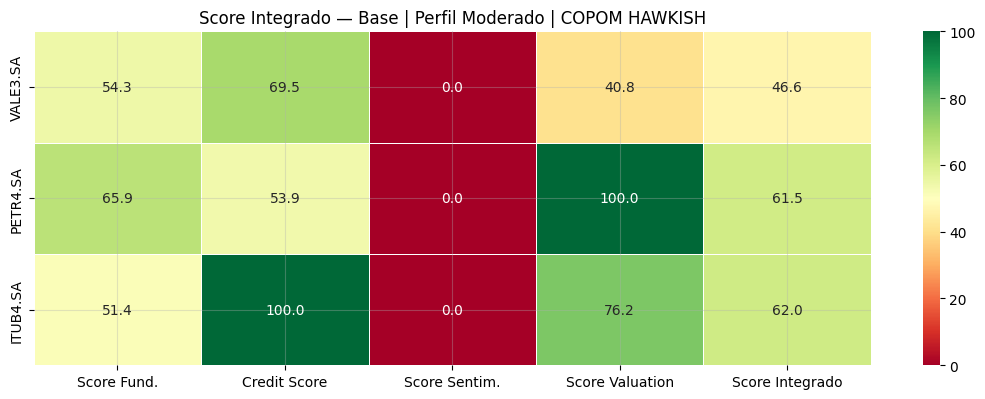

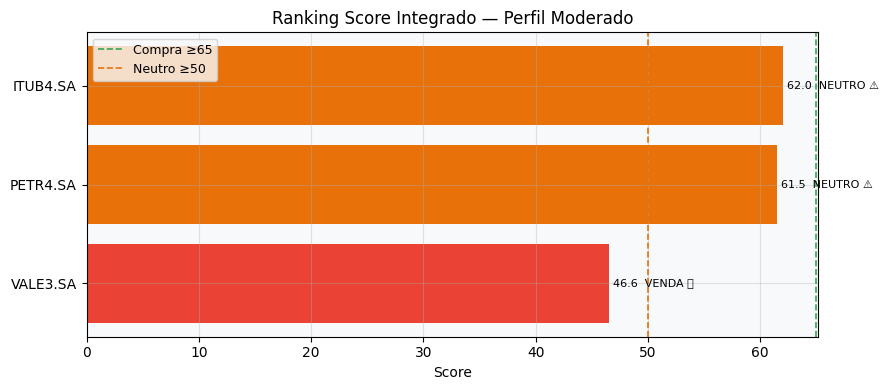

'/tmp/figs_relatorio/09_ranking_final.png'

In [89]:
# =============================================================================
# CÉLULA 12 — SCORE INTEGRADO + RECOMENDAÇÃO
# =============================================================================

pesos = {"Fundamental": 0.35, "Credito": 0.25, "Sentimento": 0.15, "Valuation": 0.25}

def score_valuation_upside(ticker):
    upside = RESULTADOS_MC.get(ticker, {}).get("upside", np.nan)
    if pd.isna(upside):
        return 50.0
    # Cenário ajusta sensibilidade
    mult = {"Bull": 1.2, "Base": 1.0, "Bear": 0.8}[CENARIO]
    return max(0, min(100, 50 + upside * 100 * mult))

def score_sentimento_hd():
    """Converte HD da última ata em score 0-100 para todas as empresas."""
    if np.isnan(ULTIMO_HD):
        return {t: 50.0 for t in TICKERS}
    # Hawkish → score menor (juros altos prejudicam equity)
    base = max(0, min(100, 50 - ULTIMO_HD * 2))
    return {t: base for t in TICKERS}

SCORE_SENT  = pd.Series(score_sentimento_hd(), name="Score_Sentimento")
SCORE_VAL   = pd.Series({t: score_valuation_upside(t) for t in TICKERS}, name="Score_Valuation")

SCORE_INTEGRADO = (
    SCORE_FUND.reindex(TICKERS).fillna(50)  * pesos["Fundamental"]
    + CREDIT["Credit_Score"].reindex(TICKERS).fillna(50) * pesos["Credito"]
    + SCORE_SENT.reindex(TICKERS).fillna(50)              * pesos["Sentimento"]
    + SCORE_VAL.reindex(TICKERS).fillna(50)               * pesos["Valuation"]
)
SCORE_INTEGRADO.name = "Score_Integrado"

THRESH = {"Conservador": (70, 55), "Moderado": (65, 50), "Agressivo": (60, 45)}[PERFIL]

RECOMENDACOES = SCORE_INTEGRADO.map(
    lambda s: "COMPRA ✅" if s >= THRESH[0] else ("NEUTRO ⚠️" if s >= THRESH[1] else "VENDA ❌"))

DASHBOARD = pd.DataFrame({
    "Setor":             pd.Series(SETORES),
    "Score Fund.":       SCORE_FUND.reindex(TICKERS),
    "Credit Score":      CREDIT["Credit_Score"].reindex(TICKERS),
    "Rating":            CREDIT["Rating_Sintetico"].reindex(TICKERS),
    "Score Sentim.":     SCORE_SENT.reindex(TICKERS),
    "Score Valuation":   SCORE_VAL.reindex(TICKERS),
    "Score Integrado":   SCORE_INTEGRADO,
    "Recomendação":      RECOMENDACOES,
}).round(1)

print(f"\n🎯 DASHBOARD INTEGRADO — Cenário {CENARIO} | Perfil {PERFIL} | COPOM: {PERFIL_COPOM}")
print("=" * 85)
print(DASHBOARD.sort_values("Score Integrado", ascending=False).to_string())

# Heatmap integrado
num_cols = ["Score Fund.","Credit Score","Score Sentim.","Score Valuation","Score Integrado"]
fig, ax = plt.subplots(figsize=(11, max(4, len(TICKERS) * 0.7 + 2)))
sns.heatmap(DASHBOARD[num_cols].astype(float), annot=True, fmt=".1f",
            cmap="RdYlGn", vmin=0, vmax=100, linewidths=0.5, ax=ax,
            annot_kws={"size": 10})
ax.set_title(f"Score Integrado — {CENARIO} | Perfil {PERFIL} | COPOM {PERFIL_COPOM}", fontsize=12)
plt.tight_layout()
salvar_fig("08_dashboard_heatmap")

# Ranking final (barras)
fig, ax = plt.subplots(figsize=(9, max(4, len(TICKERS) * 0.6 + 1)))
rank = SCORE_INTEGRADO.sort_values()
cores_rank = [CORES["verde"] if v >= THRESH[0] else CORES["laranja"] if v >= THRESH[1]
              else CORES["vermelho"] for v in rank.values]
ax.barh(rank.index, rank.values, color=cores_rank)
ax.axvline(THRESH[0], color=CORES["verde"],   ls="--", lw=1.2, label=f"Compra ≥{THRESH[0]}")
ax.axvline(THRESH[1], color=CORES["laranja"], ls="--", lw=1.2, label=f"Neutro ≥{THRESH[1]}")
ax.set_title(f"Ranking Score Integrado — Perfil {PERFIL}")
ax.set_xlabel("Score")
ax.legend(fontsize=9)
for i, (v, t) in enumerate(zip(rank.values, rank.index)):
    ax.text(v + 0.3, i, f"{v:.1f}  {RECOMENDACOES[t]}", va="center", fontsize=8)
plt.tight_layout()
salvar_fig("09_ranking_final")

## CÉLULA 13 — FRONTEIRA EFICIENTE

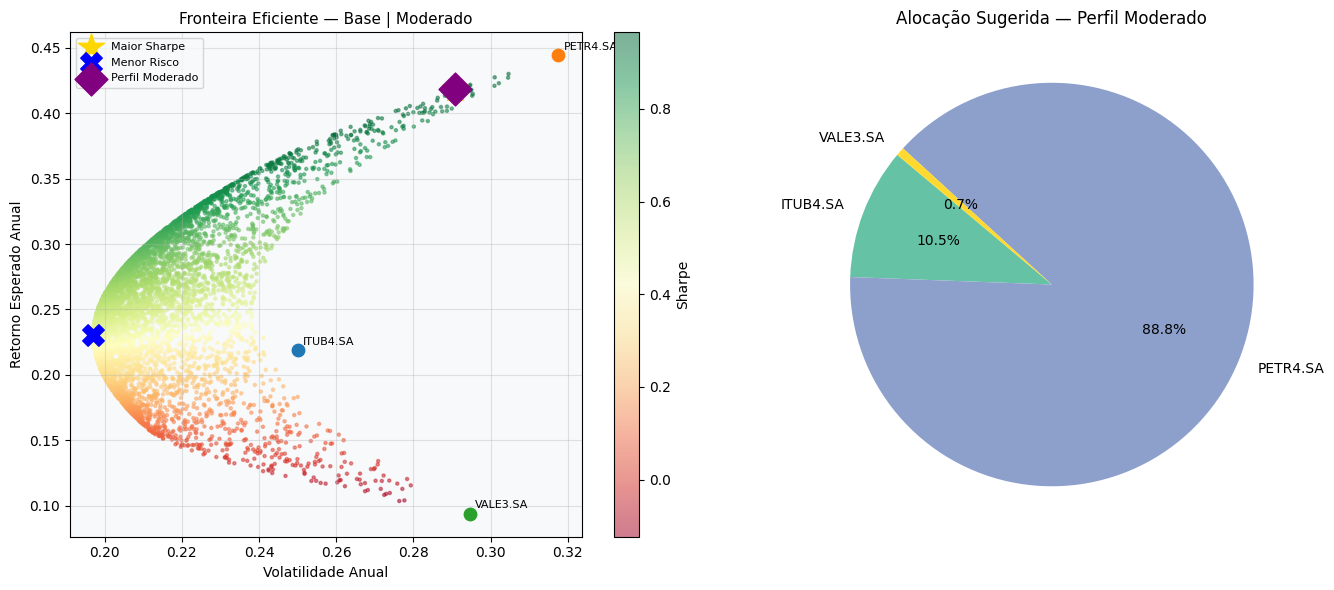


📦 Carteira Sugerida (Moderado):
   PETR4.SA    : 88.8%
   ITUB4.SA    : 10.5%
   VALE3.SA    : 0.7%
   Retorno esperado anual : 41.81%
   Volatilidade anual     : 29.07%
   Sharpe                 : 0.965


In [90]:
# =============================================================================
# CÉLULA 13 — FRONTEIRA EFICIENTE
# =============================================================================

def simular_portfolios(retornos, n_sim=6_000):
    mu  = retornos.mean() * TRADING_DAYS
    cov = retornos.cov()  * TRADING_DAYS
    n   = len(mu)
    rf  = CDI_SERIE.mean() * TRADING_DAYS
    rows = []
    for _ in range(n_sim):
        w = np.random.random(n)
        w /= w.sum()
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(cov, w)))
        sr  = (ret - rf) / max(vol, 1e-9)
        rows.append({"ret": ret, "vol": vol, "sharpe": sr, "pesos": w})
    return pd.DataFrame(rows), mu, cov


portfolios, MU, COV = simular_portfolios(RETORNOS)

best_sharpe = portfolios.loc[portfolios["sharpe"].idxmax()]
min_vol     = portfolios.loc[portfolios["vol"].idxmin()]
portfolio_perfil = (min_vol if PERFIL == "Conservador"
                    else portfolios.loc[portfolios["ret"].idxmax()] if PERFIL == "Agressivo"
                    else best_sharpe)

PESOS_SEL = pd.Series(portfolio_perfil["pesos"], index=RETORNOS.columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc = axes[0].scatter(portfolios["vol"], portfolios["ret"],
                     c=portfolios["sharpe"], cmap="RdYlGn", s=5, alpha=0.5)
plt.colorbar(sc, ax=axes[0], label="Sharpe")
axes[0].scatter(best_sharpe["vol"], best_sharpe["ret"],
                marker="*", s=380, color="gold", zorder=5, label="Maior Sharpe")
axes[0].scatter(min_vol["vol"], min_vol["ret"],
                marker="X", s=240, color="blue", zorder=5, label="Menor Risco")
axes[0].scatter(portfolio_perfil["vol"], portfolio_perfil["ret"],
                marker="D", s=280, color="purple", zorder=5, label=f"Perfil {PERFIL}")
for t in RETORNOS.columns:
    if t in MU.index:
        vt = np.sqrt(COV.loc[t, t])
        axes[0].scatter(vt, MU[t], s=80, zorder=6)
        axes[0].annotate(t, (vt, MU[t]), xytext=(4, 4),
                          textcoords="offset points", fontsize=8)
axes[0].set_title(f"Fronteira Eficiente — {CENARIO} | {PERFIL}", fontsize=11)
axes[0].set_xlabel("Volatilidade Anual")
axes[0].set_ylabel("Retorno Esperado Anual")
axes[0].legend(fontsize=8)

# Pizza pesos
axes[1].pie(PESOS_SEL.values, labels=PESOS_SEL.index,
            autopct="%1.1f%%", startangle=140,
            colors=[plt.cm.Set2(i / len(PESOS_SEL)) for i in range(len(PESOS_SEL))])
axes[1].set_title(f"Alocação Sugerida — Perfil {PERFIL}")

plt.tight_layout()
salvar_fig("10_fronteira_eficiente")

print(f"\n📦 Carteira Sugerida ({PERFIL}):")
for t, w in PESOS_SEL.sort_values(ascending=False).items():
    print(f"   {t:12s}: {w:.1%}")
print(f"   Retorno esperado anual : {portfolio_perfil['ret']:.2%}")
print(f"   Volatilidade anual     : {portfolio_perfil['vol']:.2%}")
print(f"   Sharpe                 : {portfolio_perfil['sharpe']:.3f}")

## CÉLULA 14 — BACKTEST vs CDI e IBOVESPA

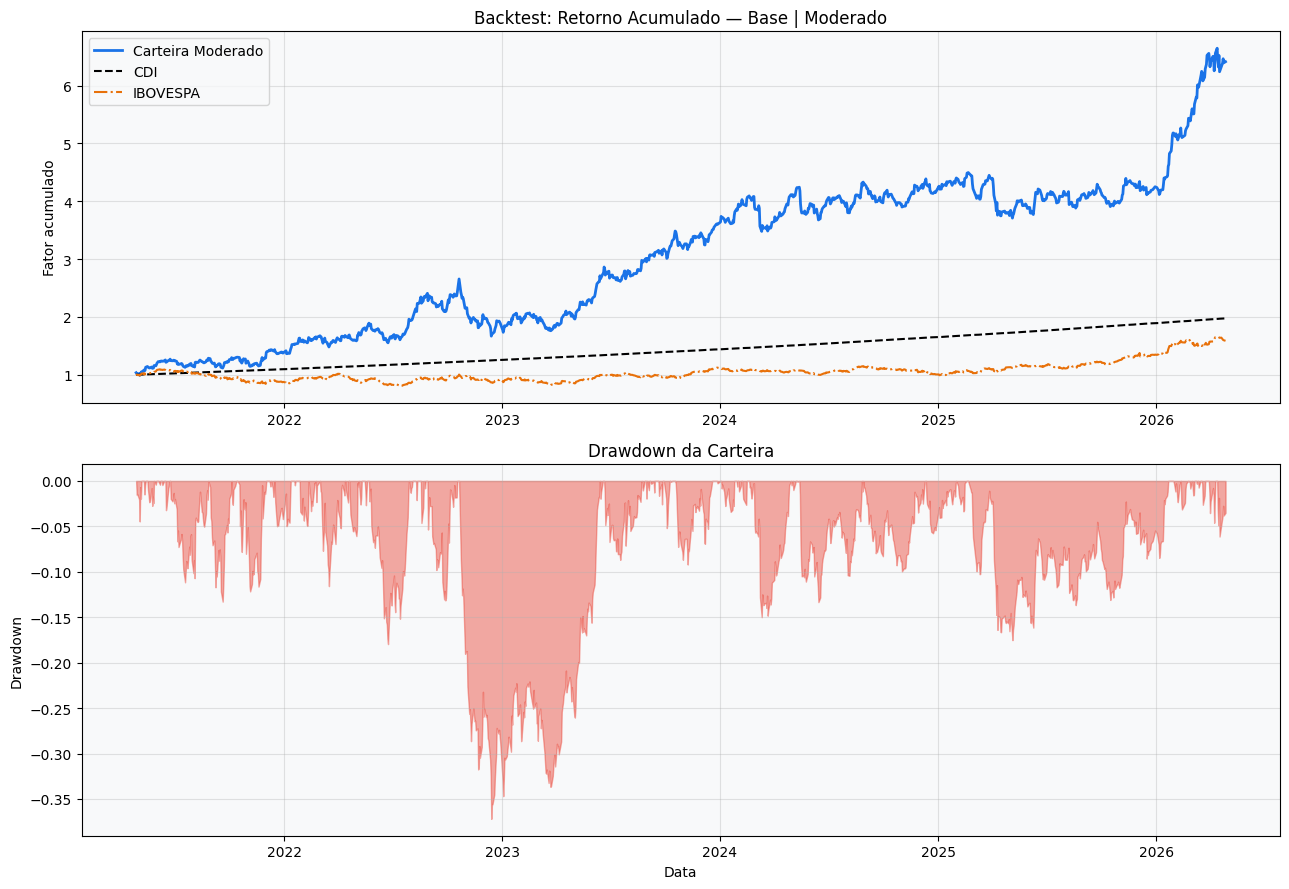


📈 Métricas Backtest — Moderado
   Retorno anual  : 41.81%
   CDI anual      : 13.76%
   Alpha vs CDI   : +28.05%
   IBOV anual     : 10.89%
   Volatilidade   : 29.07%
   Sharpe         : 0.965
   Max Drawdown   : -37.19%


In [91]:
# =============================================================================
# CÉLULA 14 — BACKTEST vs CDI e IBOVESPA
# =============================================================================

IBOV_PRECOS = baixar_precos(["^BVSP"], PERIODO)
IBOV_RET    = IBOV_PRECOS.pct_change().dropna()

def backtest_portfolio(rets, pesos):
    tickers_comuns = [t for t in pesos.index if t in rets.columns]
    w = pesos[tickers_comuns] / pesos[tickers_comuns].sum()
    return rets[tickers_comuns].dot(w)

ret_port = backtest_portfolio(RETORNOS, PESOS_SEL)
ret_port.name = f"Carteira {PERFIL}"

cdi_bt   = CDI_SERIE.reindex(ret_port.index).fillna(CDI_DIARIO_BASE)
ibov_bt  = IBOV_RET.iloc[:, 0].reindex(ret_port.index).fillna(0)
ibov_bt.name = "IBOVESPA"

acum_port = (1 + ret_port).cumprod()
acum_cdi  = (1 + cdi_bt).cumprod()
acum_ibov = (1 + ibov_bt).cumprod()
dd        = (acum_port / acum_port.cummax()) - 1

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
axes[0].plot(acum_port, lw=2,   color=CORES["azul"],    label=ret_port.name)
axes[0].plot(acum_cdi,  lw=1.5, color="black",  ls="--", label="CDI")
axes[0].plot(acum_ibov, lw=1.5, color=CORES["laranja"], ls="-.", label="IBOVESPA")
axes[0].set_title(f"Backtest: Retorno Acumulado — {CENARIO} | {PERFIL}", fontsize=12)
axes[0].set_ylabel("Fator acumulado")
axes[0].legend()

axes[1].fill_between(dd.index, dd.values, 0, color=CORES["vermelho"], alpha=0.45)
axes[1].set_title("Drawdown da Carteira")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Data")

plt.tight_layout()
salvar_fig("11_backtest")

ret_anual_bt  = ret_port.mean() * TRADING_DAYS
vol_anual_bt  = ret_port.std()  * np.sqrt(TRADING_DAYS)
cdi_anual_bt  = cdi_bt.mean()   * TRADING_DAYS
sharpe_bt     = (ret_anual_bt - cdi_anual_bt) / max(vol_anual_bt, 1e-9)
mdd_bt        = dd.min()

print(f"\n📈 Métricas Backtest — {PERFIL}")
print(f"   Retorno anual  : {ret_anual_bt:.2%}")
print(f"   CDI anual      : {cdi_anual_bt:.2%}")
print(f"   Alpha vs CDI   : {ret_anual_bt - cdi_anual_bt:+.2%}")
print(f"   IBOV anual     : {ibov_bt.mean() * TRADING_DAYS:.2%}")
print(f"   Volatilidade   : {vol_anual_bt:.2%}")
print(f"   Sharpe         : {sharpe_bt:.3f}")
print(f"   Max Drawdown   : {mdd_bt:.2%}")

## CÉLULA 15 — DETECÇÃO DE ANOMALIAS + CLUSTERIZAÇÃO

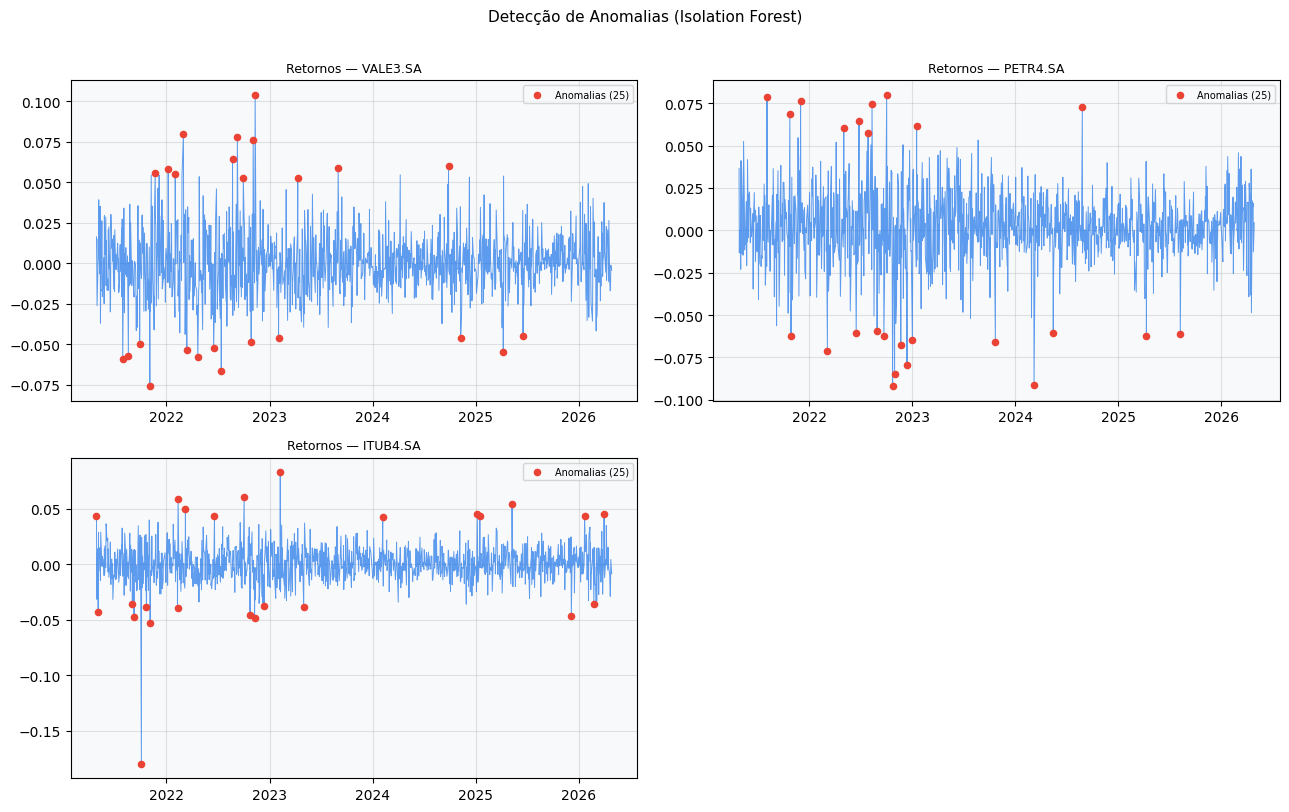

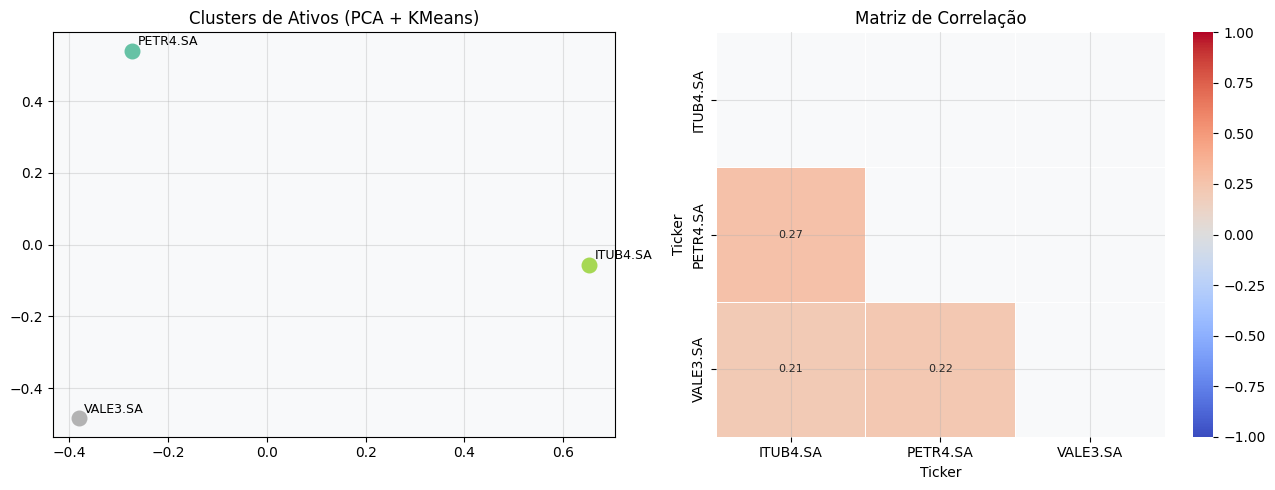

'/tmp/figs_relatorio/13_clusters_correlacao.png'

In [92]:
# =============================================================================
# CÉLULA 15 — DETECÇÃO DE ANOMALIAS + CLUSTERIZAÇÃO
# =============================================================================

# Anomalias
n_rows_anom = math.ceil(len(TICKERS) / 2)
fig, axes = plt.subplots(n_rows_anom, 2, figsize=(13, 4 * n_rows_anom))
axes = np.array(axes).flatten()

for idx, t in enumerate(TICKERS):
    if t not in RETORNOS.columns:
        axes[idx].set_visible(False)
        continue
    serie = RETORNOS[[t]].dropna()
    iso   = IsolationForest(n_estimators=200, contamination=0.02, random_state=RANDOM_STATE)
    flags = iso.fit_predict(serie)
    anom  = serie[flags == -1]
    ax = axes[idx]
    ax.plot(serie.index, serie[t], color=CORES["azul"], alpha=0.7, lw=0.7)
    ax.scatter(anom.index, anom[t], color=CORES["vermelho"], s=20, zorder=5,
               label=f"Anomalias ({len(anom)})")
    ax.set_title(f"Retornos — {t}", fontsize=9)
    ax.legend(fontsize=7)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Detecção de Anomalias (Isolation Forest)", fontsize=11, y=1.01)
plt.tight_layout()
salvar_fig("12_anomalias")

# Clusterização
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
corr = RETORNOS.corr()
X_pca    = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(corr.values)
n_cl     = min(3, len(TICKERS))
labels_k = KMeans(n_clusters=n_cl, random_state=RANDOM_STATE, n_init=20).fit_predict(X_pca)
cores_cl = plt.cm.Set2(np.linspace(0, 1, n_cl))

for i, (x, y) in enumerate(X_pca):
    axes[0].scatter(x, y, color=cores_cl[labels_k[i]], s=110)
    axes[0].annotate(TICKERS[i], (x, y), xytext=(4, 4), textcoords="offset points", fontsize=9)
axes[0].set_title("Clusters de Ativos (PCA + KMeans)")

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, ax=axes[1], linewidths=0.4,
            vmin=-1, vmax=1, annot_kws={"size": 8})
axes[1].set_title("Matriz de Correlação")

plt.tight_layout()
salvar_fig("13_clusters_correlacao")

## CÉLULA 16 — CENÁRIO MACRO CONSOLIDADO (gráfico)

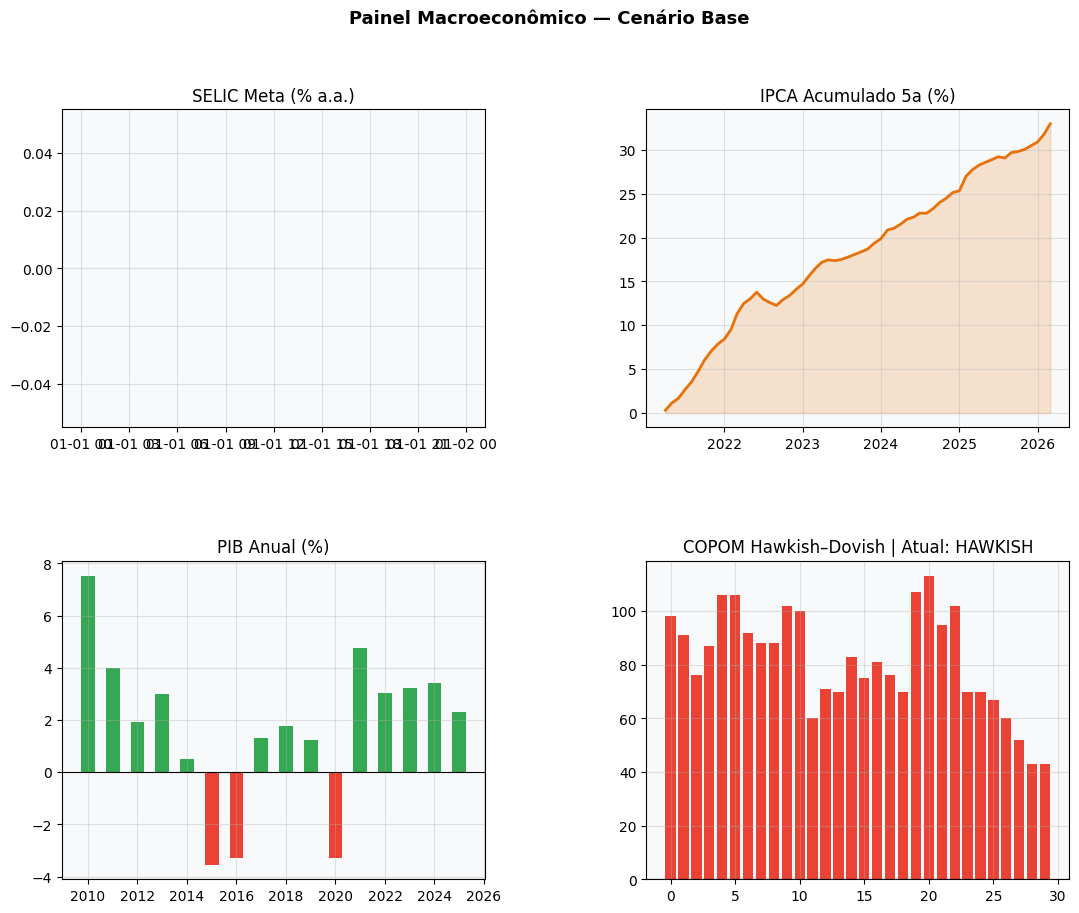

'/tmp/figs_relatorio/14_painel_macro.png'

In [93]:
# =============================================================================
# CÉLULA 16 — CENÁRIO MACRO CONSOLIDADO (gráfico)
# =============================================================================

fig = plt.figure(figsize=(13, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# SELIC
if "SELIC_meta" in MACRO_RAW.columns:
    s = MACRO_RAW["SELIC_meta"].dropna().iloc[-60:]
    ax1.plot(s.index, s.values, color=CORES["vermelho"], lw=2)
    ax1.fill_between(s.index, s.values, alpha=0.18, color=CORES["vermelho"])
ax1.set_title("SELIC Meta (% a.a.)")

# IPCA acumulado
if "IPCA_mensal" in MACRO_RAW.columns:
    ip = MACRO_RAW["IPCA_mensal"].dropna().iloc[-60:]
    acum_ip = (1 + ip / 100).cumprod() - 1
    ax2.plot(acum_ip.index, acum_ip.values * 100, color=CORES["laranja"], lw=2)
    ax2.fill_between(acum_ip.index, acum_ip.values * 100, alpha=0.18, color=CORES["laranja"])
ax2.set_title("IPCA Acumulado 5a (%)")

# PIB
if "PIB_anual" in MACRO_RAW.columns:
    pib = MACRO_RAW["PIB_anual"].dropna().iloc[-20:]
    cores_pib = [CORES["verde"] if v > 0 else CORES["vermelho"] for v in pib.values]
    ax3.bar(pib.index, pib.values, color=cores_pib, width=200)
    ax3.axhline(0, color="black", lw=0.8)
ax3.set_title("PIB Anual (%)")

# HD COPOM timeline
if not DF_COPOM.empty:
    v2 = DF_COPOM.dropna(subset=["hd_index"])
    cores_hd2 = [CORES["vermelho"] if v > 0 else CORES["azul"] for v in v2["hd_index"]]
    ax4.bar(range(len(v2)), v2["hd_index"], color=cores_hd2)
    ax4.axhline(0, color="black", lw=0.8)
ax4.set_title(f"COPOM Hawkish–Dovish | Atual: {PERFIL_COPOM}")

fig.suptitle(f"Painel Macroeconômico — Cenário {CENARIO}", fontsize=13, fontweight="bold")
salvar_fig("14_painel_macro")

## CÉLULA 17 — RELATÓRIO EXECUTIVO TEXTO

In [94]:
# =============================================================================
# CÉLULA 17 — RELATÓRIO EXECUTIVO TEXTO
# =============================================================================

print("\n" + "=" * 72)
print("  📋  RELATÓRIO EXECUTIVO — ANÁLISE INTEGRADA DE MERCADO")
print(f"  Cenário: {CENARIO} | Perfil: {PERFIL} | COPOM: {PERFIL_COPOM}")
print(f"  Data: {datetime.today().strftime('%d/%m/%Y')}")
print("=" * 72)

print("\n1️⃣  MACRO")
print(f"   SELIC: {SELIC_ATUAL:.2%} | IPCA 12m: {IPCA_12M:.2%} | g (PIB 5a): {G_PIB:.2%}")
print(f"   COPOM: {PERFIL_COPOM} — {DESCRICAO_COPOM[:80]}…")

print("\n2️⃣  RANKING")
rank = DASHBOARD.sort_values("Score Integrado", ascending=False)
for i, (t, row) in enumerate(rank.iterrows(), 1):
    print(f"   #{i} {t:12s} | {row['Setor']:12s} | Score: {row['Score Integrado']:5.1f} | "
          f"Rating: {row['Rating']:3s} | {row['Recomendação']}")

print("\n3️⃣  CARTEIRA SUGERIDA")
for t, w in PESOS_SEL.sort_values(ascending=False).items():
    print(f"   {t:12s}: {w:.1%}  [{SETORES.get(t,'?')}]")

print("\n4️⃣  PERFORMANCE BACKTEST")
print(f"   Retorno anual  : {ret_anual_bt:.2%}")
print(f"   Alpha vs CDI   : {ret_anual_bt - cdi_anual_bt:+.2%}")
print(f"   Sharpe         : {sharpe_bt:.3f}")
print(f"   Max Drawdown   : {mdd_bt:.2%}")

print("\n5️⃣  WACC E VALUATION")
for t in TICKERS:
    w_info = WACC_POR_ATIVO[t]
    up     = RESULTADOS_MC[t].get("upside", np.nan)
    up_txt = f"{up:+.1%}" if not np.isnan(up) else "N/D"
    print(f"   {t:12s}: WACC={w_info['wacc']:.2%} | Ke={w_info['Ke']:.2%} | Upside={up_txt}")

print("\n6️⃣  ALERTAS DE CRÉDITO")
for t, row in CREDIT.iterrows():
    if row["Rating_Sintetico"] in ["BB","B","CCC"]:
        print(f"   ⚠️  {t} — Rating {row['Rating_Sintetico']} | DL/EBITDA: {row['DL_EBITDA']:.1f}x")

print("\n" + "=" * 72)


  📋  RELATÓRIO EXECUTIVO — ANÁLISE INTEGRADA DE MERCADO
  Cenário: Base | Perfil: Moderado | COPOM: HAWKISH
  Data: 28/04/2026

1️⃣  MACRO
   SELIC: 14.75% | IPCA 12m: 4.14% | g (PIB 5a): 3.35%
   COPOM: HAWKISH — A última ata do COPOM apresenta viés predominantemente hawkish. O Comitê demonst…

2️⃣  RANKING
   #1 ITUB4.SA     | Financeiro   | Score:  62.0 | Rating: AAA | NEUTRO ⚠️
   #2 PETR4.SA     | Energia      | Score:  61.5 | Rating: BB  | NEUTRO ⚠️
   #3 VALE3.SA     | Energia      | Score:  46.6 | Rating: A   | VENDA ❌

3️⃣  CARTEIRA SUGERIDA
   PETR4.SA    : 88.8%  [Energia]
   ITUB4.SA    : 10.5%  [Financeiro]
   VALE3.SA    : 0.7%  [Energia]

4️⃣  PERFORMANCE BACKTEST
   Retorno anual  : 41.81%
   Alpha vs CDI   : +28.05%
   Sharpe         : 0.965
   Max Drawdown   : -37.19%

5️⃣  WACC E VALUATION
   VALE3.SA    : WACC=15.23% | Ke=16.39% | Upside=-9.2%
   PETR4.SA    : WACC=10.66% | Ke=10.15% | Upside=+117.9%
   ITUB4.SA    : WACC=11.68% | Ke=12.34% | Upside=+26.2%

6️⃣  AL

## CÉLULA 18 — EXPORTAÇÃO DO RELATÓRIO EM PDF (reportlab)

In [95]:
# =============================================================================
# CÉLULA 18 — EXPORTAÇÃO DO RELATÓRIO EM PDF (reportlab)
# =============================================================================

print("\n⏳ Gerando relatório em PDF …")

PDF_PATH = "/tmp/relatorio_mercado.pdf"

# Estilos
styles  = getSampleStyleSheet()

STYLE_TITLE = ParagraphStyle("title_custom", parent=styles["Title"],
                              fontSize=22, textColor=colors.HexColor("#1a73e8"),
                              spaceAfter=8, alignment=TA_CENTER)
STYLE_H1    = ParagraphStyle("h1_custom", parent=styles["Heading1"],
                              fontSize=14, textColor=colors.HexColor("#1a73e8"),
                              spaceBefore=14, spaceAfter=6)
STYLE_H2    = ParagraphStyle("h2_custom", parent=styles["Heading2"],
                              fontSize=11, textColor=colors.HexColor("#e8710a"),
                              spaceBefore=10, spaceAfter=4)
STYLE_BODY  = ParagraphStyle("body_custom", parent=styles["Normal"],
                              fontSize=9.5, leading=14, alignment=TA_JUSTIFY,
                              spaceAfter=6)
STYLE_SMALL = ParagraphStyle("small", parent=styles["Normal"],
                              fontSize=8, textColor=colors.gray)
STYLE_ALERT = ParagraphStyle("alert", parent=styles["Normal"],
                              fontSize=9.5, textColor=colors.HexColor("#ea4335"),
                              spaceBefore=4, spaceAfter=4)
STYLE_GREEN = ParagraphStyle("green", parent=styles["Normal"],
                              fontSize=9.5, textColor=colors.HexColor("#34a853"))

def figura_pdf(path, largura=16 * cm, altura=8 * cm):
    """Insere uma figura salva como PNG no PDF."""
    if os.path.exists(path):
        return RLImage(path, width=largura, height=altura)
    return Paragraph(f"[Figura não encontrada: {path}]", STYLE_SMALL)


def tabela_pdf(df, col_widths=None):
    """Converte DataFrame em Table do reportlab."""
    data = [list(df.columns)]
    for _, row in df.iterrows():
        data.append([str(v) for v in row.values])
    t = Table(data, colWidths=col_widths)
    t.setStyle(TableStyle([
        ("BACKGROUND",  (0, 0), (-1, 0), colors.HexColor("#1a73e8")),
        ("TEXTCOLOR",   (0, 0), (-1, 0), colors.white),
        ("FONTSIZE",    (0, 0), (-1, -1), 8),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.whitesmoke, colors.white]),
        ("GRID",        (0, 0), (-1, -1), 0.35, colors.lightgrey),
        ("ALIGN",       (0, 0), (-1, -1), "CENTER"),
        ("VALIGN",      (0, 0), (-1, -1), "MIDDLE"),
        ("TOPPADDING",  (0, 0), (-1, -1), 3),
        ("BOTTOMPADDING",(0, 0), (-1, -1), 3),
    ]))
    return t


story = []
data_str = datetime.today().strftime("%d/%m/%Y")
hora_str = datetime.today().strftime("%H:%M")

# ---- Capa ----
story.append(Spacer(1, 1.5 * cm))
story.append(Paragraph("LABORATÓRIO DE FINANÇAS QUANTITATIVAS", STYLE_TITLE))
story.append(Paragraph("Análise Integrada de Mercado", STYLE_TITLE))
story.append(Spacer(1, 0.5 * cm))
story.append(HRFlowable(width="100%", thickness=2, color=colors.HexColor("#1a73e8")))
story.append(Spacer(1, 0.4 * cm))
story.append(Paragraph(f"<b>Cenário:</b> {CENARIO} &nbsp;&nbsp; <b>Perfil:</b> {PERFIL} "
                        f"&nbsp;&nbsp; <b>Período:</b> {PERIODO}", STYLE_BODY))
story.append(Paragraph(f"<b>Data:</b> {data_str} {hora_str} &nbsp;&nbsp; "
                        f"<b>COPOM:</b> {PERFIL_COPOM}", STYLE_BODY))
story.append(Paragraph(f"<b>Ativos analisados:</b> {', '.join(TICKERS)}", STYLE_BODY))
story.append(Spacer(1, 0.5 * cm))

# ---- 1. Cenário Macro ----
story.append(Paragraph("1. Cenário Macroeconômico", STYLE_H1))
story.append(HRFlowable(width="100%", thickness=0.5, color=colors.lightgrey))
story.append(Spacer(1, 0.2 * cm))

macro_rows = [
    ["Indicador", "Valor", "Fonte"],
    ["SELIC Meta (atual)",    f"{SELIC_ATUAL:.2%}",  "BCB SGS 432"],
    ["IPCA 12 meses",         f"{IPCA_12M:.2%}",     "BCB SGS 433"],
    ["PIB médio 5 anos",      f"{G_PIB:.2%}",        "BCB SGS 7326"],
    ["g perpetuidade (DCF)",  f"{G_PERPETUIDADE:.2%}","Calculado"],
    ["CDI a.a.",              f"{CDI_AA if 'CDI_AA' in dir() else SELIC_ATUAL:.2%}", "BCB SGS 12"],
    ["Cenário ajuste g",      CENARIO,                "Usuário"],
]
t_macro = Table(macro_rows, colWidths=[6*cm, 4*cm, 5*cm])
t_macro.setStyle(TableStyle([
    ("BACKGROUND",  (0, 0), (-1, 0), colors.HexColor("#1a73e8")),
    ("TEXTCOLOR",   (0, 0), (-1, 0), colors.white),
    ("FONTSIZE",    (0, 0), (-1, -1), 9),
    ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.whitesmoke, colors.white]),
    ("GRID",        (0, 0), (-1, -1), 0.35, colors.lightgrey),
    ("ALIGN",       (1, 0), (1, -1), "CENTER"),
    ("TOPPADDING",  (0, 0), (-1, -1), 4),
    ("BOTTOMPADDING",(0, 0), (-1, -1), 4),
]))
story.append(t_macro)
story.append(Spacer(1, 0.3 * cm))
story.append(figura_pdf(os.path.join(FIG_DIR, "14_painel_macro.png"), 17*cm, 9*cm))

# ---- 2. COPOM ----
story.append(PageBreak())
story.append(Paragraph("2. Política Monetária — Análise das Atas do COPOM", STYLE_H1))
story.append(HRFlowable(width="100%", thickness=0.5, color=colors.lightgrey))
story.append(Spacer(1, 0.2 * cm))

perfil_cor = {"HAWKISH": STYLE_ALERT, "DOVISH": STYLE_GREEN, "NEUTRO": STYLE_BODY,
              "INDISPONÍVEL": STYLE_SMALL}
story.append(Paragraph(f"<b>Perfil da última ata: {PERFIL_COPOM}</b>",
                        perfil_cor.get(PERFIL_COPOM, STYLE_BODY)))
story.append(Spacer(1, 0.2 * cm))
story.append(Paragraph(DESCRICAO_COPOM, STYLE_BODY))
story.append(Spacer(1, 0.25 * cm))

if ULTIMA_ATA:
    ata_rows = [
        ["Campo", "Valor"],
        ["Número da reunião", str(int(ULTIMA_ATA.get("nroReuniao", 0)))],
        ["Data de publicação", str(ULTIMA_ATA.get("dataPublicacao", "N/D"))[:10]],
        ["Índice Hawkish–Dovish", f"{ULTIMO_HD:.0f}"],
        ["Perfil", PERFIL_COPOM],
        ["Título", str(ULTIMA_ATA.get("titulo", "N/D"))[:60]],
    ]
    t_ata = Table(ata_rows, colWidths=[7*cm, 10*cm])
    t_ata.setStyle(TableStyle([
        ("BACKGROUND",   (0, 0), (-1, 0), colors.HexColor("#e8710a")),
        ("TEXTCOLOR",    (0, 0), (-1, 0), colors.white),
        ("FONTSIZE",     (0, 0), (-1, -1), 9),
        ("ROWBACKGROUNDS",(0,1),(-1,-1),[colors.whitesmoke, colors.white]),
        ("GRID",         (0, 0), (-1, -1), 0.35, colors.lightgrey),
        ("TOPPADDING",   (0, 0), (-1, -1), 4),
        ("BOTTOMPADDING",(0, 0), (-1, -1), 4),
    ]))
    story.append(t_ata)

story.append(Spacer(1, 0.3 * cm))
story.append(figura_pdf(os.path.join(FIG_DIR, "06_copom_hd.png"), 17*cm, 8.5*cm))

# ---- 3. WACC ----
story.append(PageBreak())
story.append(Paragraph("3. Custo de Capital (WACC) por Empresa", STYLE_H1))
story.append(HRFlowable(width="100%", thickness=0.5, color=colors.lightgrey))
story.append(Spacer(1, 0.2 * cm))
story.append(Paragraph(
    "WACC calculado via CAPM com taxa livre de risco real (SELIC – IPCA), "
    "prêmio de risco ajustado ao cenário, spread de crédito setorial e "
    "estrutura de capital (E/D) extraída do yfinance.", STYLE_BODY))
story.append(Spacer(1, 0.2 * cm))

df_wacc_pdf = df_wacc.copy()
df_wacc_pdf = df_wacc_pdf.applymap(lambda x: f"{x:.2%}" if isinstance(x, float) and abs(x) < 10 else str(round(x, 3)))
df_wacc_pdf = df_wacc_pdf.reset_index()
story.append(tabela_pdf(df_wacc_pdf))
story.append(Spacer(1, 0.3 * cm))
story.append(figura_pdf(os.path.join(FIG_DIR, "01_wacc.png"), 15*cm, 6*cm))

# ---- 4. Score Fundamental ----
story.append(PageBreak())
story.append(Paragraph("4. Score Fundamental e Credit Score", STYLE_H1))
story.append(HRFlowable(width="100%", thickness=0.5, color=colors.lightgrey))

story.append(Paragraph("4.1 Score Fundamental", STYLE_H2))
story.append(figura_pdf(os.path.join(FIG_DIR, "04_score_fundamental.png"), 15*cm, 6*cm))

story.append(Paragraph("4.2 Credit Score e Indicadores de Crédito", STYLE_H2))
story.append(figura_pdf(os.path.join(FIG_DIR, "05_credit_score.png"), 17*cm, 7*cm))
story.append(Spacer(1, 0.2 * cm))

credit_pdf = CREDIT.reset_index()[["ticker","Credit_Score","Rating_Sintetico",
                                    "DL_EBITDA","Liquidez_Corrente"]]
story.append(tabela_pdf(credit_pdf.rename(columns={
    "ticker":"Ticker","Credit_Score":"Score","Rating_Sintetico":"Rating",
    "DL_EBITDA":"DL/EBITDA","Liquidez_Corrente":"Liq. Corrente"})))

# ---- 5. Valuation DCF ----
story.append(PageBreak())
story.append(Paragraph("5. Valuation DCF via Simulação de Monte Carlo", STYLE_H1))
story.append(HRFlowable(width="100%", thickness=0.5, color=colors.lightgrey))
story.append(Spacer(1, 0.2 * cm))
story.append(Paragraph(
    f"Simulação com 8.000 cenários por ativo. WACC calculado individualmente. "
    f"g de perpetuidade = {G_PERPETUIDADE:.2%} (média PIB 5a, ajuste {CENARIO}).",
    STYLE_BODY))
story.append(figura_pdf(os.path.join(FIG_DIR, "07_valuation_mc.png"), 17*cm, 10*cm))
story.append(Spacer(1, 0.2 * cm))

mc_pdf = df_mc.reset_index().rename(columns={"index":"Ticker"})
story.append(tabela_pdf(mc_pdf))

# ---- 6. Dashboard Integrado ----
story.append(PageBreak())
story.append(Paragraph("6. Dashboard Integrado — Score e Recomendações", STYLE_H1))
story.append(HRFlowable(width="100%", thickness=0.5, color=colors.lightgrey))
story.append(Spacer(1, 0.2 * cm))
story.append(figura_pdf(os.path.join(FIG_DIR, "08_dashboard_heatmap.png"), 17*cm, 7*cm))
story.append(Spacer(1, 0.2 * cm))
story.append(figura_pdf(os.path.join(FIG_DIR, "09_ranking_final.png"), 15*cm, 6*cm))
story.append(Spacer(1, 0.2 * cm))

dash_pdf = DASHBOARD.reset_index().rename(columns={"index":"Ticker"})
story.append(tabela_pdf(dash_pdf))

# ---- 7. Fronteira Eficiente ----
story.append(PageBreak())
story.append(Paragraph("7. Fronteira Eficiente e Carteira Sugerida", STYLE_H1))
story.append(HRFlowable(width="100%", thickness=0.5, color=colors.lightgrey))
story.append(figura_pdf(os.path.join(FIG_DIR, "10_fronteira_eficiente.png"), 17*cm, 8.5*cm))
story.append(Spacer(1, 0.2 * cm))

pesos_rows = [["Ativo", "Peso (%)", "Setor"]]
for t, w in PESOS_SEL.sort_values(ascending=False).items():
    pesos_rows.append([t, f"{w:.1%}", SETORES.get(t, "?")])
t_pesos = Table(pesos_rows, colWidths=[5*cm, 4*cm, 6*cm])
t_pesos.setStyle(TableStyle([
    ("BACKGROUND",   (0, 0), (-1, 0), colors.HexColor("#7b1fa2")),
    ("TEXTCOLOR",    (0, 0), (-1, 0), colors.white),
    ("FONTSIZE",     (0, 0), (-1, -1), 9),
    ("ROWBACKGROUNDS",(0,1),(-1,-1),[colors.whitesmoke, colors.white]),
    ("GRID",         (0, 0), (-1, -1), 0.35, colors.lightgrey),
    ("ALIGN",        (1, 0), (1, -1), "CENTER"),
    ("TOPPADDING",   (0, 0), (-1, -1), 4),
    ("BOTTOMPADDING",(0, 0), (-1, -1), 4),
]))
story.append(t_pesos)

# ---- 8. Backtest ----
story.append(PageBreak())
story.append(Paragraph("8. Backtest da Carteira vs Benchmarks", STYLE_H1))
story.append(HRFlowable(width="100%", thickness=0.5, color=colors.lightgrey))
story.append(figura_pdf(os.path.join(FIG_DIR, "11_backtest.png"), 17*cm, 9*cm))
story.append(Spacer(1, 0.2 * cm))

bt_rows = [
    ["Métrica", "Carteira", "CDI", "IBOVESPA"],
    ["Retorno Anual",   f"{ret_anual_bt:.2%}",
                        f"{cdi_anual_bt:.2%}",
                        f"{ibov_bt.mean()*TRADING_DAYS:.2%}"],
    ["Alpha vs CDI",    f"{ret_anual_bt - cdi_anual_bt:+.2%}", "—", "—"],
    ["Volatilidade",    f"{vol_anual_bt:.2%}", "~0%",
                        f"{ibov_bt.std()*np.sqrt(TRADING_DAYS):.2%}"],
    ["Sharpe",          f"{sharpe_bt:.3f}", "—", "—"],
    ["Max Drawdown",    f"{mdd_bt:.2%}", "N/A", "—"],
]
t_bt = Table(bt_rows, colWidths=[5.5*cm, 4.5*cm, 4.5*cm, 4*cm])
t_bt.setStyle(TableStyle([
    ("BACKGROUND",   (0, 0), (-1, 0), colors.HexColor("#1a73e8")),
    ("TEXTCOLOR",    (0, 0), (-1, 0), colors.white),
    ("FONTSIZE",     (0, 0), (-1, -1), 9),
    ("ROWBACKGROUNDS",(0,1),(-1,-1),[colors.whitesmoke, colors.white]),
    ("GRID",         (0, 0), (-1, -1), 0.35, colors.lightgrey),
    ("ALIGN",        (1, 0), (-1, -1), "CENTER"),
    ("TOPPADDING",   (0, 0), (-1, -1), 4),
    ("BOTTOMPADDING",(0, 0), (-1, -1), 4),
]))
story.append(t_bt)

# ---- 9. Retorno + Anomalias + Correlação ----
story.append(PageBreak())
story.append(Paragraph("9. Retornos, Anomalias e Correlação", STYLE_H1))
story.append(HRFlowable(width="100%", thickness=0.5, color=colors.lightgrey))
story.append(figura_pdf(os.path.join(FIG_DIR, "02_retorno_acumulado.png"), 17*cm, 9*cm))
story.append(figura_pdf(os.path.join(FIG_DIR, "03_boxplot_retornos.png"), 15*cm, 5.5*cm))
story.append(figura_pdf(os.path.join(FIG_DIR, "12_anomalias.png"), 17*cm, 8*cm))
story.append(figura_pdf(os.path.join(FIG_DIR, "13_clusters_correlacao.png"), 17*cm, 7*cm))

# ---- 10. Estatísticas ----
story.append(PageBreak())
story.append(Paragraph("10. Estatísticas Descritivas dos Retornos", STYLE_H1))
story.append(HRFlowable(width="100%", thickness=0.5, color=colors.lightgrey))
story.append(Spacer(1, 0.2 * cm))
stats_pdf = STATS.reset_index().rename(columns={"index": "Ticker"})
story.append(tabela_pdf(stats_pdf))

# ---- 11. Conclusão ----
story.append(PageBreak())
story.append(Paragraph("11. Conclusão e Alertas", STYLE_H1))
story.append(HRFlowable(width="100%", thickness=0.5, color=colors.lightgrey))
story.append(Spacer(1, 0.3 * cm))

conclusao_text = (
    f"A análise foi conduzida sob o <b>Cenário {CENARIO}</b>, com perfil de investidor "
    f"<b>{PERFIL}</b>, considerando a política monetária atual do Banco Central do Brasil "
    f"(<b>COPOM {PERFIL_COPOM}</b>). "
    f"A taxa SELIC de <b>{SELIC_ATUAL:.2%} a.a.</b> e a inflação de <b>{IPCA_12M:.2%}</b> "
    f"nos últimos 12 meses foram incorporadas automaticamente ao cálculo do WACC individual "
    f"de cada empresa via modelo CAPM, com prêmio de risco ajustado ao cenário. "
    f"O crescimento de perpetuidade (g = <b>{G_PERPETUIDADE:.2%}</b>) foi derivado da "
    f"média histórica de 5 anos do PIB, com ajuste pelo cenário selecionado. "
)
story.append(Paragraph(conclusao_text, STYLE_BODY))
story.append(Spacer(1, 0.3 * cm))

# Top recomendações
story.append(Paragraph("Top Recomendações:", STYLE_H2))
rank_final = DASHBOARD.sort_values("Score Integrado", ascending=False)
for i, (t, row) in enumerate(rank_final.iterrows(), 1):
    cor_st = STYLE_GREEN if "COMPRA" in str(row["Recomendação"]) \
             else (STYLE_ALERT if "VENDA" in str(row["Recomendação"]) else STYLE_BODY)
    story.append(Paragraph(
        f"#{i} <b>{t}</b> [{row['Setor']}] — Score: {row['Score Integrado']:.1f} | "
        f"Rating: {row['Rating']} | {row['Recomendação']}",
        cor_st))

story.append(Spacer(1, 0.3 * cm))

# Alertas de crédito
story.append(Paragraph("Alertas de Crédito:", STYLE_H2))
alerts = CREDIT[CREDIT["Rating_Sintetico"].isin(["BB","B","CCC"])]
if alerts.empty:
    story.append(Paragraph("Nenhum alerta de crédito identificado.", STYLE_BODY))
else:
    for t, row in alerts.iterrows():
        story.append(Paragraph(
            f"⚠ <b>{t}</b> — Rating {row['Rating_Sintetico']} | "
            f"DL/EBITDA: {row['DL_EBITDA']:.1f}x | "
            f"Liq. Corrente: {row['Liquidez_Corrente']:.2f}",
            STYLE_ALERT))

story.append(Spacer(1, 0.5 * cm))
story.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor("#1a73e8")))
story.append(Spacer(1, 0.2 * cm))
story.append(Paragraph(
    "Relatório gerado por Caio, Fernando Tinoco, Leonardo Galvão e Sergio.",
    STYLE_SMALL))
story.append(Paragraph(
    "⚠ Este material é exclusivamente educacional e não constitui recomendação de investimento.",
    STYLE_SMALL))

# Build PDF
doc = SimpleDocTemplate(
    PDF_PATH,
    pagesize=A4,
    rightMargin=1.8*cm, leftMargin=1.8*cm,
    topMargin=2*cm, bottomMargin=1.8*cm,
    title="Relatório Integrado de Mercado",
    author="Caio, Fernando Tinoco, Leonardo Galvão e Sergio",
)
doc.build(story)

from google.colab import files
files.download(PDF_PATH)
print(f"✅ PDF gerado e download iniciado: {PDF_PATH}")
print(f"   Figuras incluídas: {len(FIG_PATHS)}")


⏳ Gerando relatório em PDF …


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ PDF gerado e download iniciado: /tmp/relatorio_mercado.pdf
   Figuras incluídas: 15
